# Packages

In [1]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import contextily as cx
import xarray as xr
from datetime import datetime, timedelta

import matplotlib.pyplot as plt
from matplotlib import cm

from sklearn.metrics import (mean_squared_error,
                             mean_absolute_error,
                             mean_absolute_percentage_error)
from scipy.stats import pearsonr

from cmaqpy.runcmaq import CMAQModel
from cmaqpy import plots
from cmaqpy import utils
import monetio as mio

## Read 2018 CMAQ data

In [2]:
winter_sim_2018 = {
    'start_date': utils.format_date('2018-01-01'),
    'end_date': utils.format_date('2018-01-08'),
    'base_case_dir': '/mnt/Bo_HDD2/cmaq_data/CMAQ_v5.4/data/2018-01-01_2018-01-08_2018_12US1/post',
    'nygrid_case_dir': '/mnt/Bo_HDD2/cmaq_data/CMAQ_v5.4/data/2018-01-01_2018-01-08_2018_12US1_nygrid/post',
}

summer_sim_2018 = {
    'start_date': utils.format_date('2018-07-02'),
    'end_date': utils.format_date('2018-07-09'),
    'base_case_dir': '/mnt/Bo_HDD2/cmaq_data/CMAQ_v5.4/data/2018-07-02_2018-07-09_2018_12US1/post',
    'nygrid_case_dir': '/mnt/Bo_HDD2/cmaq_data/CMAQ_v5.4/data/2018-07-02_2018-07-09_2018_12US1_nygrid/post',
}

In [3]:
conc_pfx = "COMBINE_ACONC_v54_gcc11.3.0"
dep_pfx = "COMBINE_DEP_v54_gcc11.3.0"

# Base case winter
app = "2018_12US1"
conc_winter_base_2018 = mio.cmaq.open_mfdataset(
    os.path.join(winter_sim_2018['base_case_dir'],
                 f"{conc_pfx}_{app}_{winter_sim_2018['start_date'].strftime('%Y%m')}.nc"))
dep_winter_base_2018 = mio.cmaq.open_mfdataset(
    os.path.join(winter_sim_2018['base_case_dir'],
                 f"{dep_pfx}_{app}_{winter_sim_2018['start_date'].strftime('%Y%m')}"))

# Base case summer
conc_summer_base_2018 = mio.cmaq.open_mfdataset(
    os.path.join(summer_sim_2018['base_case_dir'],
                 f"{conc_pfx}_{app}_{summer_sim_2018['start_date'].strftime('%Y%m')}.nc"))
dep_summer_base_2018 = mio.cmaq.open_mfdataset(
    os.path.join(summer_sim_2018['base_case_dir'],
                 f"{dep_pfx}_{app}_{summer_sim_2018['start_date'].strftime('%Y%m')}"))

# NYGrid case winter
app = "2018_12US1_nygrid"
conc_winter_nygrid_2018 = mio.cmaq.open_mfdataset(
    os.path.join(winter_sim_2018['nygrid_case_dir'],
                 f"{conc_pfx}_{app}_{winter_sim_2018['start_date'].strftime('%Y%m')}.nc"))
dep_winter_nygrid_2018 = mio.cmaq.open_mfdataset(
    os.path.join(winter_sim_2018['nygrid_case_dir'],
                 f"{dep_pfx}_{app}_{winter_sim_2018['start_date'].strftime('%Y%m')}"))

# NYGrid case summer
conc_summer_nygrid_2018 = mio.cmaq.open_mfdataset(
    os.path.join(summer_sim_2018['nygrid_case_dir'],
                 f"{conc_pfx}_{app}_{summer_sim_2018['start_date'].strftime('%Y%m')}.nc"))
dep_summer_nygrid_2018 = mio.cmaq.open_mfdataset(
    os.path.join(summer_sim_2018['nygrid_case_dir'],
                 f"{dep_pfx}_{app}_{summer_sim_2018['start_date'].strftime('%Y%m')}"))

/home/by276/anaconda3/envs/optwrf_new/lib/python3.7/site-packages/pyproj/crs/crs.py:1256: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  return self._crs.to_proj4(version=version)
/home/by276/anaconda3/envs/optwrf_new/lib/python3.7/site-packages/pyproj/crs/crs.py:1256: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  return self._crs.to_proj4(version=version)
/home/by276/anaconda3/envs/optwrf_new/lib/python3.7/site-packages/pyproj/crs/crs.py:1256: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinat

In [4]:
# Convert all to Eastern Time
conc_winter_base_2018 = utils.convert_tz_xr(conc_winter_base_2018)
conc_winter_nygrid_2018 = utils.convert_tz_xr(conc_winter_nygrid_2018)
conc_summer_base_2018 = utils.convert_tz_xr(conc_summer_base_2018)
conc_summer_nygrid_2018 = utils.convert_tz_xr(conc_summer_nygrid_2018)

# Get map projections and boundaries
ccrs = plots.get_proj(conc_winter_base_2018)
proj_bounds = plots.get_domain_boundary(conc_winter_base_2018, ccrs)

## Read 2032 CMAQ data

In [5]:
winter_sim_2030BaselineCase = {
    'start_date': utils.format_date('2018-01-01'),
    'end_date': utils.format_date('2018-01-08'),
    'base_case_dir': '/mnt/Bo_HDD2/cmaq_data/CMAQ_v5.4/data/2018-01-01_2018-01-08_2032_12US1/post',
    'nygrid_case_dir': '/mnt/Bo_HDD2/cmaq_data/CMAQ_v5.4/data/2018-01-01_2018-01-08_2032_12US1_nygrid_2030BaselineCase/post',
}

summer_sim_2030BaselineCase = {
    'start_date': utils.format_date('2018-07-02'),
    'end_date': utils.format_date('2018-07-09'),
    'base_case_dir': '/mnt/Bo_HDD2/cmaq_data/CMAQ_v5.4/data/2018-07-02_2018-07-09_2032_12US1/post',
    'nygrid_case_dir': '/mnt/Bo_HDD2/cmaq_data/CMAQ_v5.4/data/2018-07-02_2018-07-09_2032_12US1_nygrid_2030BaselineCase/post',
}

winter_sim_2030ContractCase = {
    'start_date': utils.format_date('2018-01-01'),
    'end_date': utils.format_date('2018-01-08'),
    'base_case_dir': '/mnt/Bo_HDD2/cmaq_data/CMAQ_v5.4/data/2018-01-01_2018-01-08_2032_12US1/post',
    'nygrid_case_dir': '/mnt/Bo_HDD2/cmaq_data/CMAQ_v5.4/data/2018-01-01_2018-01-08_2032_12US1_nygrid_2030ContractCase/post',
}

summer_sim_2030ContractCase = {
    'start_date': utils.format_date('2018-07-02'),
    'end_date': utils.format_date('2018-07-09'),
    'base_case_dir': '/mnt/Bo_HDD2/cmaq_data/CMAQ_v5.4/data/2018-07-02_2018-07-09_2032_12US1/post',
    'nygrid_case_dir': '/mnt/Bo_HDD2/cmaq_data/CMAQ_v5.4/data/2018-07-02_2018-07-09_2032_12US1_nygrid_2030ContractCase/post',
}

winter_sim_2030StateScenario = {
    'start_date': utils.format_date('2018-01-01'),
    'end_date': utils.format_date('2018-01-08'),
    'base_case_dir': '/mnt/Bo_HDD2/cmaq_data/CMAQ_v5.4/data/2018-01-01_2018-01-08_2032_12US1/post',
    'nygrid_case_dir': '/mnt/Bo_HDD2/cmaq_data/CMAQ_v5.4/data/2018-01-01_2018-01-08_2032_12US1_nygrid_2030StateScenario/post',
}

summer_sim_2030StateScenario = {
    'start_date': utils.format_date('2018-07-02'),
    'end_date': utils.format_date('2018-07-09'),
    'base_case_dir': '/mnt/Bo_HDD2/cmaq_data/CMAQ_v5.4/data/2018-07-02_2018-07-09_2032_12US1/post',
    'nygrid_case_dir': '/mnt/Bo_HDD2/cmaq_data/CMAQ_v5.4/data/2018-07-02_2018-07-09_2032_12US1_nygrid_2030StateScenario/post',
}

In [6]:
conc_pfx = "COMBINE_ACONC_v54_gcc11.3.0"
dep_pfx = "COMBINE_DEP_v54_gcc11.3.0"

## EPA
### Base case winter
app = "2032_12US1"
conc_winter_base_2032 = mio.cmaq.open_mfdataset(
    os.path.join(winter_sim_2030BaselineCase['base_case_dir'],
                 f"{conc_pfx}_{app}_{winter_sim_2030BaselineCase['start_date'].strftime('%Y%m')}.nc"))
dep_winter_base_2032 = mio.cmaq.open_mfdataset(
    os.path.join(winter_sim_2030BaselineCase['base_case_dir'],
                 f"{dep_pfx}_{app}_{winter_sim_2030BaselineCase['start_date'].strftime('%Y%m')}"))

### Base case summer
conc_summer_base_2032 = mio.cmaq.open_mfdataset(
    os.path.join(summer_sim_2030BaselineCase['base_case_dir'],
                 f"{conc_pfx}_{app}_{summer_sim_2030BaselineCase['start_date'].strftime('%Y%m')}.nc"))
dep_summer_base_2032 = mio.cmaq.open_mfdataset(
    os.path.join(summer_sim_2030BaselineCase['base_case_dir'],
                 f"{dep_pfx}_{app}_{summer_sim_2030BaselineCase['start_date'].strftime('%Y%m')}"))

## NYGrid case winter
### 1) 2030BaselineCase
app = "2032_12US1_nygrid"
conc_winter_nygrid_2030BaselineCase = mio.cmaq.open_mfdataset(
    os.path.join(winter_sim_2030BaselineCase['nygrid_case_dir'],
                 f"{conc_pfx}_{app}_{winter_sim_2030BaselineCase['start_date'].strftime('%Y%m')}.nc"))
dep_winter_nygrid_2030BaselineCase = mio.cmaq.open_mfdataset(
    os.path.join(winter_sim_2030BaselineCase['nygrid_case_dir'],
                 f"{dep_pfx}_{app}_{winter_sim_2030BaselineCase['start_date'].strftime('%Y%m')}"))

conc_summer_nygrid_2030BaselineCase = mio.cmaq.open_mfdataset(
    os.path.join(summer_sim_2030BaselineCase['nygrid_case_dir'],
                 f"{conc_pfx}_{app}_{summer_sim_2030BaselineCase['start_date'].strftime('%Y%m')}.nc"))
dep_summer_nygrid_2030BaselineCase = mio.cmaq.open_mfdataset(
    os.path.join(summer_sim_2030BaselineCase['nygrid_case_dir'],
                 f"{dep_pfx}_{app}_{summer_sim_2030BaselineCase['start_date'].strftime('%Y%m')}"))

### 2) 2030ContractCase
app = "2032_12US1_nygrid"
conc_winter_nygrid_2030ContractCase = mio.cmaq.open_mfdataset(
    os.path.join(winter_sim_2030ContractCase['nygrid_case_dir'],
                 f"{conc_pfx}_{app}_{winter_sim_2030ContractCase['start_date'].strftime('%Y%m')}.nc"))
dep_winter_nygrid_2030ContractCase = mio.cmaq.open_mfdataset(
    os.path.join(winter_sim_2030ContractCase['nygrid_case_dir'],
                 f"{dep_pfx}_{app}_{winter_sim_2030ContractCase['start_date'].strftime('%Y%m')}"))

conc_summer_nygrid_2030ContractCase = mio.cmaq.open_mfdataset(
    os.path.join(summer_sim_2030ContractCase['nygrid_case_dir'],
                 f"{conc_pfx}_{app}_{summer_sim_2030ContractCase['start_date'].strftime('%Y%m')}.nc"))
dep_summer_nygrid_2030ContractCase = mio.cmaq.open_mfdataset(
    os.path.join(summer_sim_2030ContractCase['nygrid_case_dir'],
                 f"{dep_pfx}_{app}_{summer_sim_2030ContractCase['start_date'].strftime('%Y%m')}"))

### 3) 2030StateScenario
app = "2032_12US1_nygrid"
conc_winter_nygrid_2030StateScenario = mio.cmaq.open_mfdataset(
    os.path.join(winter_sim_2030StateScenario['nygrid_case_dir'],
                 f"{conc_pfx}_{app}_{winter_sim_2030StateScenario['start_date'].strftime('%Y%m')}.nc"))
dep_winter_nygrid_2030StateScenario = mio.cmaq.open_mfdataset(
    os.path.join(winter_sim_2030StateScenario['nygrid_case_dir'],
                 f"{dep_pfx}_{app}_{winter_sim_2030StateScenario['start_date'].strftime('%Y%m')}"))

conc_summer_nygrid_2030StateScenario = mio.cmaq.open_mfdataset(
    os.path.join(summer_sim_2030StateScenario['nygrid_case_dir'],
                 f"{conc_pfx}_{app}_{summer_sim_2030StateScenario['start_date'].strftime('%Y%m')}.nc"))
dep_summer_nygrid_2030StateScenario = mio.cmaq.open_mfdataset(
    os.path.join(summer_sim_2030StateScenario['nygrid_case_dir'],
                 f"{dep_pfx}_{app}_{summer_sim_2030StateScenario['start_date'].strftime('%Y%m')}"))

/home/by276/anaconda3/envs/optwrf_new/lib/python3.7/site-packages/pyproj/crs/crs.py:1256: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  return self._crs.to_proj4(version=version)
/home/by276/anaconda3/envs/optwrf_new/lib/python3.7/site-packages/pyproj/crs/crs.py:1256: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  return self._crs.to_proj4(version=version)
/home/by276/anaconda3/envs/optwrf_new/lib/python3.7/site-packages/pyproj/crs/crs.py:1256: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinat

In [7]:
# 2030BaselineCase winter
filedir = '/mnt/Bo_HDD2/cmaq_data/CMAQ_v5.4/data/2018-01-01_2018-01-08_2032_12US1_nygrid_2030BaselineCase/output_CCTM_v54_gcc11.3.0_2032_12US1_nygrid'
filename = 'CCTM_ACONC_v54_gcc11.3.0_2032_12US1_nygrid_20180101.nc'
ds_winter_nygrid_2030BaselineCase = mio.cmaq.open_mfdataset(os.path.join(filedir, filename))

filedir = '/mnt/Bo_HDD2/cmaq_data/CMAQ_v5.4/data/2018-07-02_2018-07-09_2032_12US1_nygrid_2030BaselineCase/output_CCTM_v54_gcc11.3.0_2032_12US1_nygrid'
filename = 'CCTM_ACONC_v54_gcc11.3.0_2032_12US1_nygrid_20180702.nc'
ds_summer_nygrid_2030BaselineCase = mio.cmaq.open_mfdataset(os.path.join(filedir, filename))

# 2030ContractCase winter
filedir = '/mnt/Bo_HDD2/cmaq_data/CMAQ_v5.4/data/2018-01-01_2018-01-08_2032_12US1_nygrid_2030ContractCase/output_CCTM_v54_gcc11.3.0_2032_12US1_nygrid'
filename = 'CCTM_ACONC_v54_gcc11.3.0_2032_12US1_nygrid_20180101.nc'
ds_winter_nygrid_2030ContractCase = mio.cmaq.open_mfdataset(os.path.join(filedir, filename))

filedir = '/mnt/Bo_HDD2/cmaq_data/CMAQ_v5.4/data/2018-07-02_2018-07-09_2032_12US1_nygrid_2030ContractCase/output_CCTM_v54_gcc11.3.0_2032_12US1_nygrid'
filename = 'CCTM_ACONC_v54_gcc11.3.0_2032_12US1_nygrid_20180702.nc'
ds_summer_nygrid_2030ContractCase = mio.cmaq.open_mfdataset(os.path.join(filedir, filename))

# 2030StateScenario winter
filedir = '/mnt/Bo_HDD2/cmaq_data/CMAQ_v5.4/data/2018-01-01_2018-01-08_2032_12US1_nygrid_2030StateScenario/output_CCTM_v54_gcc11.3.0_2032_12US1_nygrid'
filename = 'CCTM_ACONC_v54_gcc11.3.0_2032_12US1_nygrid_20180101.nc'
ds_winter_nygrid_2030StateScenario = mio.cmaq.open_mfdataset(os.path.join(filedir, filename))

filedir = '/mnt/Bo_HDD2/cmaq_data/CMAQ_v5.4/data/2018-07-02_2018-07-09_2032_12US1_nygrid_2030StateScenario/output_CCTM_v54_gcc11.3.0_2032_12US1_nygrid'
filename = 'CCTM_ACONC_v54_gcc11.3.0_2032_12US1_nygrid_20180702.nc'
ds_summer_nygrid_2030StateScenario = mio.cmaq.open_mfdataset(os.path.join(filedir, filename))

/home/by276/anaconda3/envs/optwrf_new/lib/python3.7/site-packages/pyproj/crs/crs.py:1256: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  return self._crs.to_proj4(version=version)
/home/by276/anaconda3/envs/optwrf_new/lib/python3.7/site-packages/pyproj/crs/crs.py:1256: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  return self._crs.to_proj4(version=version)
/home/by276/anaconda3/envs/optwrf_new/lib/python3.7/site-packages/pyproj/crs/crs.py:1256: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinat

In [8]:
var = 'O3'
ds_winter_2030BC = ds_winter_nygrid_2030BaselineCase[var].sel(time='2018-01-01T16:00:00').to_numpy()
ds_winter_2030CC = ds_winter_nygrid_2030ContractCase[var].sel(time='2018-01-01T16:00:00').to_numpy()
ds_winter_2030SS = ds_winter_nygrid_2030StateScenario[var].sel(time='2018-01-01T16:00:00').to_numpy()

ds_summer_2030BC = ds_summer_nygrid_2030BaselineCase[var].sel(time='2018-07-02T16:00:00').to_numpy()
ds_summer_2030CC = ds_summer_nygrid_2030ContractCase[var].sel(time='2018-07-02T16:00:00').to_numpy()
ds_summer_2030SS = ds_summer_nygrid_2030StateScenario[var].sel(time='2018-07-02T16:00:00').to_numpy()

In [9]:
print('BC-CC winter:', (ds_winter_2030BC - ds_winter_2030CC).sum())
print('BC-SS winter:', (ds_winter_2030BC - ds_winter_2030SS).sum())
print('CC-SS winter:', (ds_winter_2030CC - ds_winter_2030SS).sum())

print('BC-CC summer:', (ds_summer_2030BC - ds_summer_2030CC).sum())
print('BC-SS summer:', (ds_summer_2030BC - ds_summer_2030SS).sum())
print('CC-SS summer:', (ds_summer_2030CC - ds_summer_2030SS).sum())

BC-CC winter: -5.7106113
BC-SS winter: -7.191121
CC-SS winter: -1.4805095
BC-CC summer: 88.64729
BC-SS summer: 162.82318
CC-SS summer: 74.17592


In [10]:
var = 'O3'
conc_winter_2030BC = conc_winter_nygrid_2030BaselineCase[var].sel(time='2018-01-01T16:00:00').to_numpy()
conc_winter_2030CC = conc_winter_nygrid_2030ContractCase[var].sel(time='2018-01-01T16:00:00').to_numpy()
conc_winter_2030SS = conc_winter_nygrid_2030StateScenario[var].sel(time='2018-01-01T16:00:00').to_numpy()

conc_summer_2030BC = conc_summer_nygrid_2030BaselineCase[var].sel(time='2018-07-02T16:00:00').to_numpy()
conc_summer_2030CC = conc_summer_nygrid_2030ContractCase[var].sel(time='2018-07-02T16:00:00').to_numpy()
conc_summer_2030SS = conc_summer_nygrid_2030StateScenario[var].sel(time='2018-07-02T16:00:00').to_numpy()

In [11]:
print('BC-CC winter:', (conc_winter_2030BC - conc_winter_2030CC).sum())
print('BC-SS winter:', (conc_winter_2030BC - conc_winter_2030SS).sum())
print('CC-SS winter:', (conc_winter_2030CC - conc_winter_2030SS).sum())

print('BC-CC summer:', (conc_summer_2030BC - conc_summer_2030CC).sum())
print('BC-SS summer:', (conc_summer_2030BC - conc_summer_2030SS).sum())
print('CC-SS summer:', (conc_summer_2030CC - conc_summer_2030SS).sum())

BC-CC winter: -5.7106113
BC-SS winter: -7.191121
CC-SS winter: -1.4805095
BC-CC summer: 88.64729
BC-SS summer: 162.82318
CC-SS summer: 74.17592


In [12]:
# Convert all to Eastern Time
conc_winter_base_2032 = utils.convert_tz_xr(conc_winter_base_2032)
conc_summer_base_2032 = utils.convert_tz_xr(conc_summer_base_2032)

conc_winter_nygrid_2030BaselineCase = utils.convert_tz_xr(
    conc_winter_nygrid_2030BaselineCase)
conc_summer_nygrid_2030BaselineCase = utils.convert_tz_xr(
    conc_summer_nygrid_2030BaselineCase)

conc_winter_nygrid_2030ContractCase = utils.convert_tz_xr(
    conc_winter_nygrid_2030ContractCase)
conc_summer_nygrid_2030ContractCase = utils.convert_tz_xr(
    conc_summer_nygrid_2030ContractCase)

conc_winter_nygrid_2030StateScenario = utils.convert_tz_xr(
    conc_winter_nygrid_2030StateScenario)
conc_summer_nygrid_2030StateScenario = utils.convert_tz_xr(
    conc_summer_nygrid_2030StateScenario)

## 1. Read AirNOW data

In [13]:
def airnow_data_format(data: pd.DataFrame,
                       start_date: datetime,
                       end_date: datetime) -> pd.DataFrame:

    sites = data['Site/Site AQS/Param/POC'].unique()

    site_data_list = list()
    for site in sites:
        site_name = site.split('/')[0]
        site_data = data[data['Site/Site AQS/Param/POC'] == site]
        site_data = site_data.drop(columns=['Site/Site AQS/Param/POC'])
        site_data = site_data.set_index('Date (LST)')
        site_data.index = pd.to_datetime(site_data.index)

        # site_daily_avg = site_data['Average']
        # site_daily_max = site_data['Max']
        site_data = site_data.drop(columns=['Average', 'Max'])

        # Unstack the dataframe
        site_data_combined = list()
        for idx, row in site_data.iterrows():
            time_index = pd.date_range(idx, idx+timedelta(hours=23), freq='H')
            daily_data = pd.DataFrame(
                {site_name: row.values}, index=time_index)
            site_data_combined.append(daily_data)
        site_data_combined = pd.concat(site_data_combined)
        site_data_combined.name = site_name
        site_data_list.append(site_data_combined)

    time_index = pd.date_range(
        start_date, end_date+timedelta(hours=23), freq='H')
    site_data_df = pd.concat(site_data_list, axis=1)

    return site_data_df

In [14]:
airnow_dir = '/mnt/Bo_HDD2/cmaq_data/CMAQ_v5.4/cmaqpy/data/airnow'
assert os.path.exists(airnow_dir), f"Path {airnow_dir} does not exist"

airnow_winter_site_data = dict()
winter_dates_pfx = f"{winter_sim_2018['start_date'].strftime('%Y-%m-%d')}_{winter_sim_2018['end_date'].strftime('%Y-%m-%d')}"
airnow_winter_site_data['O3'] = pd.read_csv(os.path.join(
    airnow_dir, f'{winter_dates_pfx}_hourly_ozone_ppb.csv'))
airnow_winter_site_data['O3'] = airnow_data_format(
    airnow_winter_site_data['O3'], winter_sim_2018['start_date'], winter_sim_2018['end_date'])
airnow_winter_site_data['PM25'] = pd.read_csv(os.path.join(
    airnow_dir, f'{winter_dates_pfx}_hourly_pm25_ugm3.csv'))
airnow_winter_site_data['PM25'] = airnow_data_format(
    airnow_winter_site_data['PM25'], winter_sim_2018['start_date'], winter_sim_2018['end_date'])

airnow_summer_site_data = dict()
summer_dates_pfx = f"{summer_sim_2018['start_date'].strftime('%Y-%m-%d')}_{summer_sim_2018['end_date'].strftime('%Y-%m-%d')}"
airnow_summer_site_data['O3'] = pd.read_csv(os.path.join(
    airnow_dir, f'{summer_dates_pfx}_hourly_ozone_ppb.csv'))
airnow_summer_site_data['O3'] = airnow_data_format(
    airnow_summer_site_data['O3'], summer_sim_2018['start_date'], summer_sim_2018['end_date'])
airnow_summer_site_data['PM25'] = pd.read_csv(os.path.join(
    airnow_dir, f'{summer_dates_pfx}_hourly_pm25_ugm3.csv'))
airnow_summer_site_data['PM25'] = airnow_data_format(
    airnow_summer_site_data['PM25'], summer_sim_2018['start_date'], summer_sim_2018['end_date'])

In [15]:
# Read AirNow site locations
airnow_sites = pd.read_csv(os.path.join(
    airnow_dir, 'NYS_airnow_site_location.csv'))
airnow_sites.head()

,Name,Lat,Lon
0,Albany,42.64225,-73.75457
1,Bklyn - PS 314,40.64182,-74.01865
2,Bklyn - PS274,40.69454,-73.92769
3,Bronx - IS52,40.81617,-73.90200
4,Bronx - IS74,40.81551,-73.88555


In [16]:
site_names = set(airnow_winter_site_data['O3'].columns) & set(airnow_winter_site_data['PM25'].columns) \
    & set(airnow_summer_site_data['O3'].columns) & set(airnow_summer_site_data['PM25'].columns) \
    & set(airnow_sites['Name'])
site_names = list(site_names)
site_names.sort()
airnow_sites_sel = airnow_sites[airnow_sites['Name'].isin(
    site_names)].reset_index(drop=True)
airnow_sites_sel

,Name,Lat,Lon
0,CCNY,40.81973,-73.94823
1,E Syracuse,43.05235,-76.05918
2,Holtsville,40.82799,-73.05754
3,Pinnacle State,42.09115,-77.20988
4,Queens,40.73625,-73.82165
5,Rochester,43.14618,-77.54821
6,Rockland Cty,41.18210,-74.02816
7,White Plains,41.05189,-73.76364


## 2. Read weather station data

In [17]:
weather_station_dir = '/mnt/Bo_HDD2/cmaq_data/CMAQ_v5.4/cmaqpy/data/weather_station'
assert os.path.exists(
    weather_station_dir), f"Path {weather_station_dir} does not exist"

weather_station_dict = {
    'CCNY': 'KNYC',
    'E Syracuse': 'KSYR',
    'Holtsville': 'KISP',
    'Pinnacle State ': 'KELM',
    'Queens': 'KLGA',
    'Rochester': 'KROC',
    'Rockland Cty': 'KHPN',
    'White Plains': 'KHPN',
}

weather_station_vars = {'temperature': 'Temperature (C)',
                        'relative humidity': 'Relative Humidity (%)',
                        'wind direction': 'Wind Direction (deg)',
                        'wind speed': 'Wind Speed (m/s)',
                        'solar radiation': 'Solar Radiation (W/m^2)'}

for key in weather_station_vars.keys():
    airnow_winter_site_data[key] = list()
    airnow_summer_site_data[key] = list()

for airnow_site_name, weather_station_name in weather_station_dict.items():
    print(airnow_site_name, weather_station_name)
    filename = f'{weather_station_dict[airnow_site_name]}_2018010100_2018123123.csv'
    weather_station_data = pd.read_csv(os.path.join(weather_station_dir, filename),
                                       index_col=0, parse_dates=True)

    # Retrieve data for the winter simulation period
    weather_station_data = weather_station_data[winter_sim_2018['start_date']:
                                                winter_sim_2018['end_date']+timedelta(hours=23)]
    weather_station_data = weather_station_data[weather_station_vars.keys()]

    # Convert temperature from Fahrenheit to Celsius
    weather_station_data['temperature'] = (
        weather_station_data['temperature'] - 32) * 5/9

    # Convert solar radiation from Langley to W/m^2
    weather_station_data['solar radiation'] = weather_station_data['solar radiation'] * 11.6

    # Convert wind speed from mph to m/s
    weather_station_data['wind speed'] = weather_station_data['wind speed'] * 0.44704

    # Add to the dictionary
    for key, value in weather_station_vars.items():
        airnow_winter_site_data[key].append(
            weather_station_data[key].rename(airnow_site_name))

    # Retrieve data for the summer simulation period
    weather_station_data = pd.read_csv(os.path.join(weather_station_dir, filename),
                                       index_col=0, parse_dates=True)
    weather_station_data = weather_station_data[summer_sim_2018['start_date']:
                                                summer_sim_2018['end_date']+timedelta(hours=23)]
    weather_station_data = weather_station_data[weather_station_vars.keys()]

    # Convert temperature from Fahrenheit to Celsius
    weather_station_data['temperature'] = (
        weather_station_data['temperature'] - 32) * 5/9

    # Convert solar radiation from Langley to W/m^2
    weather_station_data['solar radiation'] = weather_station_data['solar radiation'] * 11.6

    # Convert wind speed from mph to m/s
    weather_station_data['wind speed'] = weather_station_data['wind speed'] * 0.44704

    # Add to the dictionary
    for key, value in weather_station_vars.items():
        airnow_summer_site_data[key].append(
            weather_station_data[key].rename(airnow_site_name))

for key in weather_station_vars.keys():
    airnow_winter_site_data[key] = pd.concat(
        airnow_winter_site_data[key], axis=1)
    airnow_summer_site_data[key] = pd.concat(
        airnow_summer_site_data[key], axis=1)

CCNY KNYC
E Syracuse KSYR
Holtsville KISP
Pinnacle State  KELM
Queens KLGA
Rochester KROC
Rockland Cty KHPN
White Plains KHPN


## 3. Retrieve CMAQ data at airnow locations

In [18]:
def get_cmaq_site_data(airnow_sites: pd.DataFrame,
                       cmaq_data: xr.Dataset,
                       vars: list) -> pd.DataFrame:

    data_combined = dict()
    for var in vars:
        data_combined[var] = list()

    for idx, row in airnow_sites.iterrows():
        site_name = row['Name']
        site_lat = row['Lat']
        site_lon = row['Lon']
        # print(f"Site: {site_name}, Lat: {site_lat}, Lon: {site_lon}")

        # Get the CMAQ grid cell that the site is in
        site_c = cmaq_data.monet.nearest_latlon(lat=site_lat,
                                                lon=site_lon)
        site_c = site_c.drop_vars(['latitude', 'longitude']).squeeze()

        for var in vars:
            site_var = site_c[var].to_dataframe().rename(
                columns={var: site_name})
            data_combined[var].append(site_var)

    for var in vars:
        data_combined[var] = pd.concat(data_combined[var], axis=1)

    return data_combined

In [19]:
# Get CMAQ data for AirNow sites
vars = ['PM25', 'O3', 'RH', 'SFC_TMP', 'SOL_RAD', 'WSPD10', 'WDIR10']

# CMAQ Base case 2018
cmaq_winter_site_data_2018 = get_cmaq_site_data(
    airnow_sites_sel, conc_winter_base_2018, vars)
cmaq_summer_site_data_2018 = get_cmaq_site_data(
    airnow_sites_sel, conc_summer_base_2018, vars)

# CMAQ NYGrid case 2018
cmaq_winter_nygrid_site_data_2018 = get_cmaq_site_data(
    airnow_sites_sel, conc_winter_nygrid_2018, vars)
cmaq_summer_nygrid_site_data_2018 = get_cmaq_site_data(
    airnow_sites_sel, conc_summer_nygrid_2018, vars)

# CMAQ Base case 2032
cmaq_winter_site_data_2032 = get_cmaq_site_data(
    airnow_sites_sel, conc_winter_base_2032, vars)
cmaq_summer_site_data_2032 = get_cmaq_site_data(
    airnow_sites_sel, conc_summer_base_2032, vars)

# CMAQ NYGrid case 2030BaselineCase
cmaq_winter_nygrid_site_data_2030BaselineCase = get_cmaq_site_data(
    airnow_sites_sel, conc_winter_nygrid_2030BaselineCase, vars)
cmaq_summer_nygrid_site_data_2030BaselineCase = get_cmaq_site_data(
    airnow_sites_sel, conc_summer_nygrid_2030BaselineCase, vars)


# CMAQ NYGrid case 2030ContractCase
cmaq_winter_nygrid_site_data_2030ContractCase = get_cmaq_site_data(
    airnow_sites_sel, conc_winter_nygrid_2030ContractCase, vars)
cmaq_summer_nygrid_site_data_2030ContractCase = get_cmaq_site_data(
    airnow_sites_sel, conc_summer_nygrid_2030ContractCase, vars)


# CMAQ NYGrid case 2030StateScenario
cmaq_winter_nygrid_site_data_2030StateScenario = get_cmaq_site_data(
    airnow_sites_sel, conc_winter_nygrid_2030StateScenario, vars)
cmaq_summer_nygrid_site_data_2030StateScenario = get_cmaq_site_data(
    airnow_sites_sel, conc_summer_nygrid_2030StateScenario, vars)

# Plotting

In [20]:
fig_dir = '/mnt/Bo_HDD2/cmaq_data/CMAQ_v5.4/cmaqpy/notebooks/figures'
os.makedirs(fig_dir, exist_ok=True)

## 1. AirNow Site timeseries

In [21]:
def metrics_with_nan(y_true, y_pred, squared=True):
    # Filter out NaN values
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    y_true_filtered = y_true[mask]
    y_pred_filtered = y_pred[mask]

    # Calculate root mean squared error (RMSE)
    rmse = mean_squared_error(
        y_true_filtered, y_pred_filtered, squared=squared)

    # Calculate mean absolute error (MAE)
    mae = mean_absolute_error(y_true_filtered, y_pred_filtered)

    # Calculate mean absolute percentage error (MAPE)
    # mape = mean_absolute_percentage_error(y_true_filtered, y_pred_filtered)

    # Calculate Pearson correlation
    pearson_corr, _ = pearsonr(y_true_filtered, y_pred_filtered)

    metrics = {
        'RMSE': rmse,
        'MAE': mae,
        # 'MAPE': mape,
        'Pearson R': pearson_corr
    }

    return metrics

In [22]:
def plot_site_comparison(
        # airnow_site_data,
        # cmaq_base_site_data_1,
        # cmaq_base_site_data_2,
        cmaq_nygrid_site_data_1,
        cmaq_nygrid_site_data_2,
        cmaq_nygrid_site_data_3,
        cmaq_nygrid_site_data_4,
        start_date,
        end_date,
        title,
        xlabel,
        ylabel,
        fontsize=12):

    fig, ax = plt.subplots(figsize=(12, 6))
    # ax.plot(airnow_site_data, label='Observation', color='lightgray')
    # ax.plot(cmaq_base_site_data_1, label='CMAQ EPA 2018', color='red', linestyle='--')
    # ax.plot(cmaq_base_site_data_2, label='CMAQ EPA 2030', color='orange')

    # Clip by start and end date
    cmaq_nygrid_site_data_1 = cmaq_nygrid_site_data_1[start_date:end_date]
    cmaq_nygrid_site_data_2 = cmaq_nygrid_site_data_2[start_date:end_date]
    cmaq_nygrid_site_data_3 = cmaq_nygrid_site_data_3[start_date:end_date]
    cmaq_nygrid_site_data_4 = cmaq_nygrid_site_data_4[start_date:end_date]
    
    ax.plot(cmaq_nygrid_site_data_1, label='2018NewParams',
            color='tab:blue', linestyle='--')
    ax.plot(cmaq_nygrid_site_data_2,
            label='2030BaselineCase', color='tab:orange')
    ax.plot(cmaq_nygrid_site_data_3, label='2030ContractCase', color='tab:green')
    ax.plot(cmaq_nygrid_site_data_4, label='2030StateScenario', color='tab:red')

    ax.set_title(title, fontsize=fontsize+2)
    ax.set_xlabel(xlabel, fontsize=fontsize+2)
    ax.set_ylabel(ylabel, fontsize=fontsize+2)
    ax.tick_params(axis='both', labelsize=fontsize)
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    ax.legend(loc='upper right', fontsize=fontsize)

    return fig, ax

### 1.1. Winter PM2.5

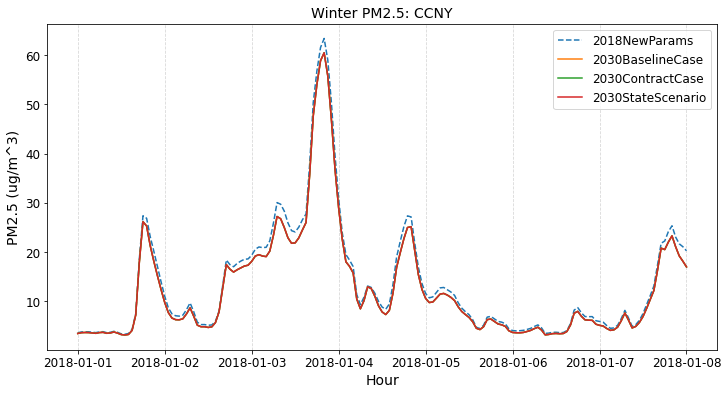

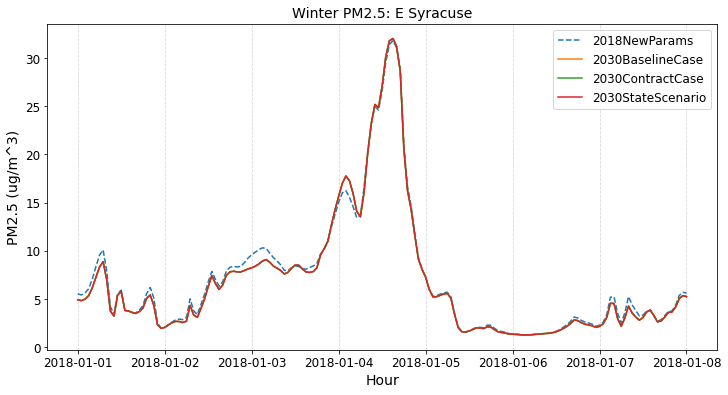

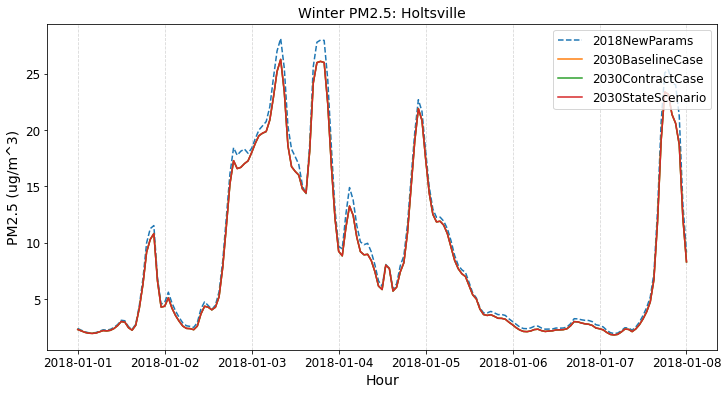

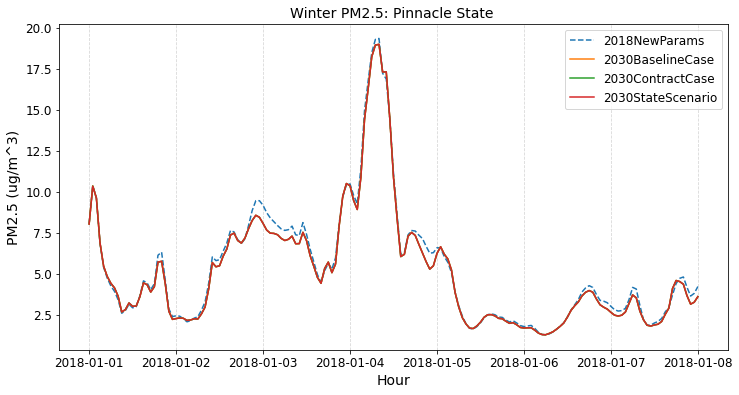

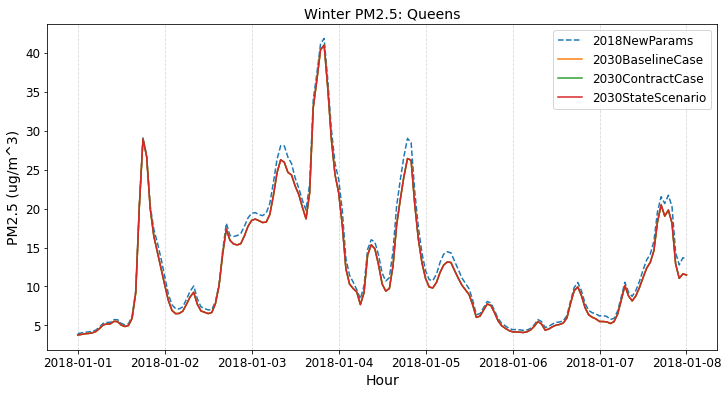

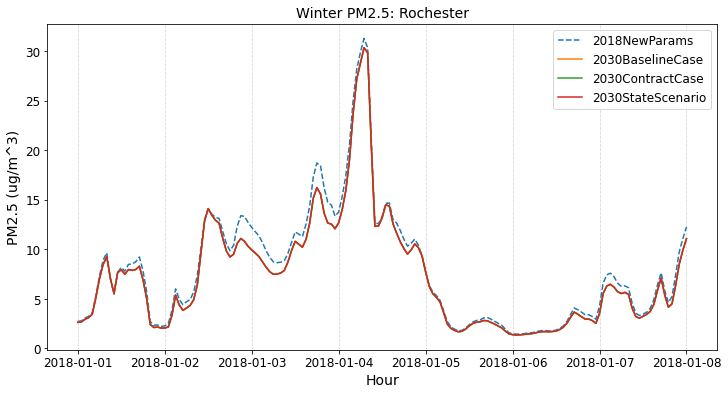

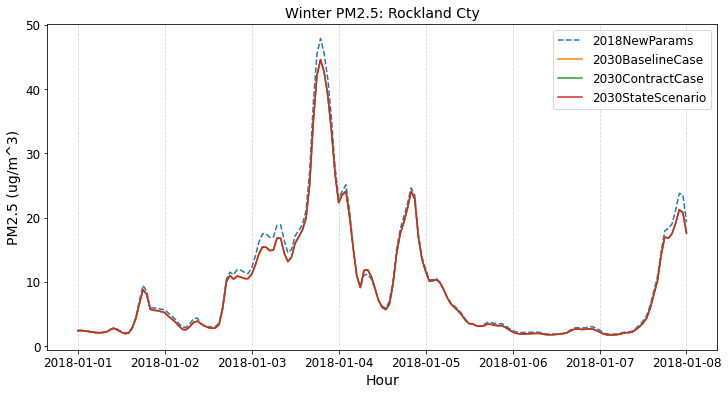

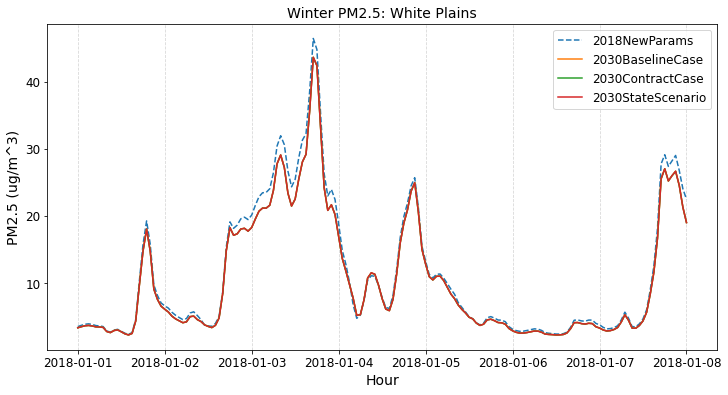

In [23]:
for site_name in site_names:
    fig, ax = plot_site_comparison(
        # airnow_site_data=airnow_winter_site_data['PM25'][site_name],
        # cmaq_base_site_data_1=cmaq_winter_site_data_2018['PM25'][site_name],
        # cmaq_base_site_data_2=cmaq_winter_site_data_2032['PM25'][site_name],
        cmaq_nygrid_site_data_1=cmaq_winter_nygrid_site_data_2018['PM25'][site_name],
        cmaq_nygrid_site_data_2=cmaq_winter_nygrid_site_data_2030BaselineCase[
            'PM25'][site_name],
        cmaq_nygrid_site_data_3=cmaq_winter_nygrid_site_data_2030ContractCase[
            'PM25'][site_name],
        cmaq_nygrid_site_data_4=cmaq_winter_nygrid_site_data_2030StateScenario[
            'PM25'][site_name],
        start_date=winter_sim_2018['start_date'],
        end_date=winter_sim_2018['end_date'],
        title=f'Winter PM2.5: {site_name}',
        xlabel='Hour',
        ylabel='PM2.5 (ug/m^3)',
        fontsize=12
    )
    fig.savefig(os.path.join(
        fig_dir, f'2030_winter_PM25_{site_name}.png'), dpi=300)

### 1.2 Summer PM2.5

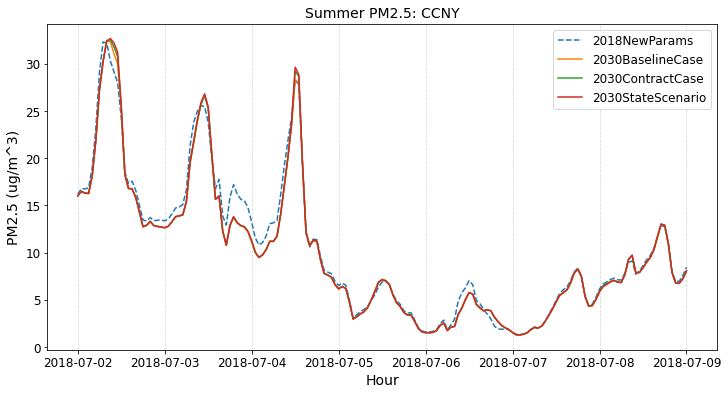

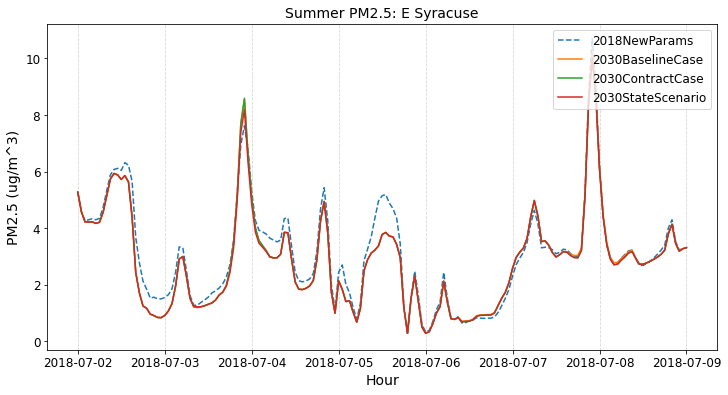

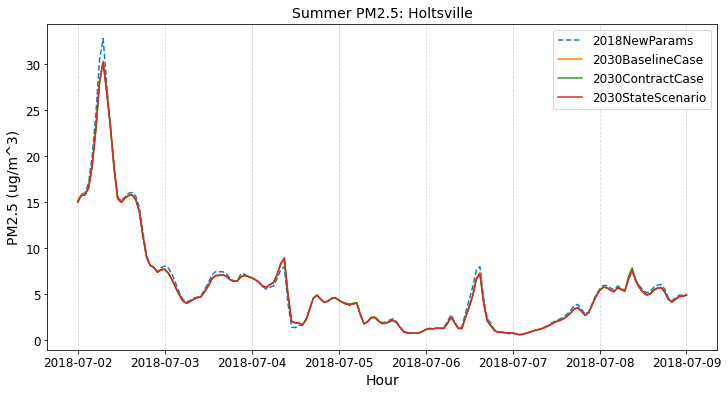

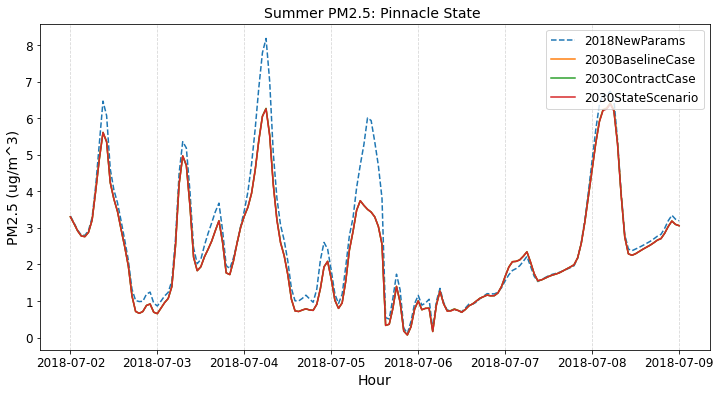

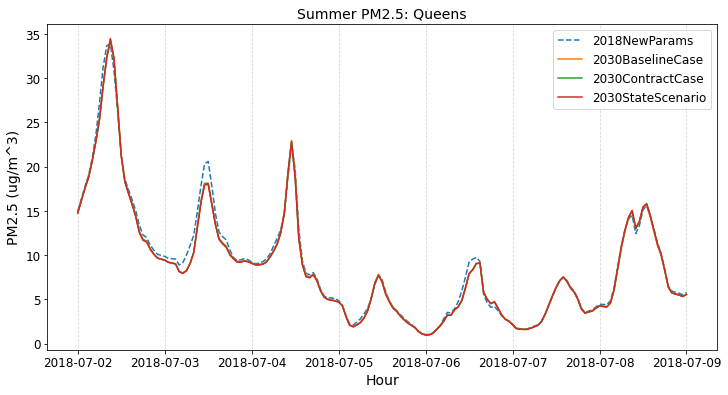

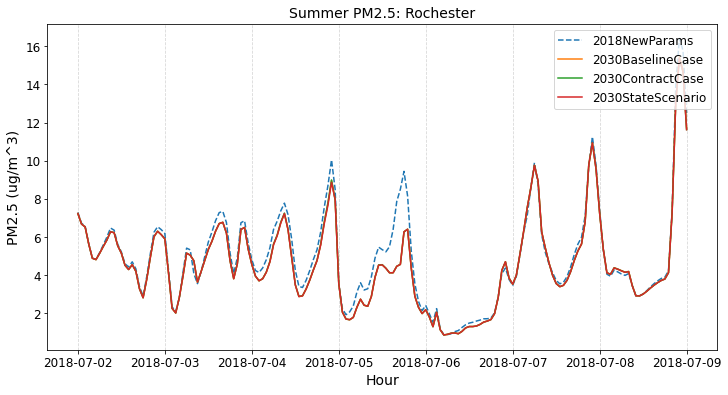

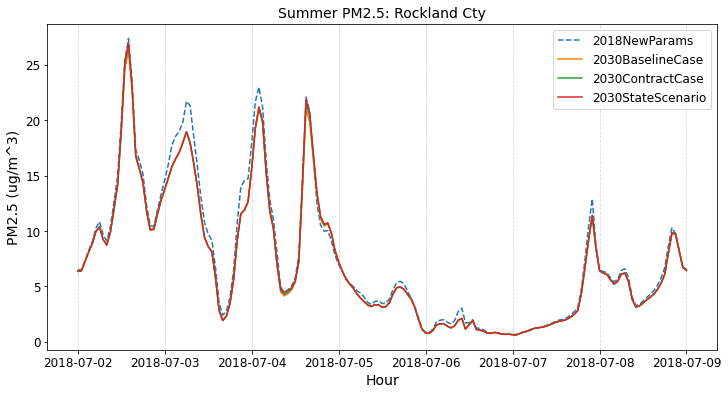

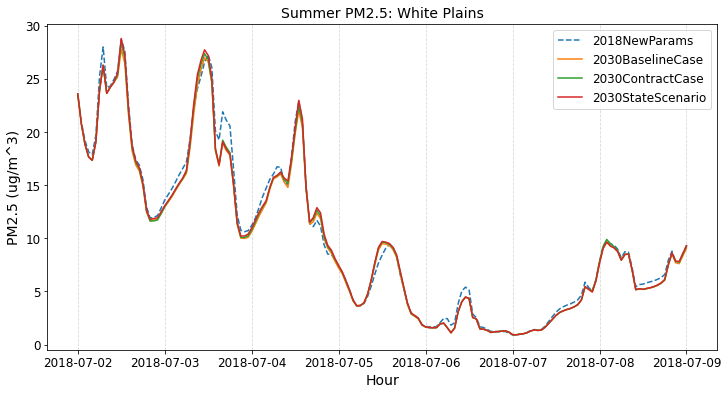

In [24]:
for site_name in site_names:
    fig, ax = plot_site_comparison(
        # airnow_summer_site_data['PM25'][site_name],
        # cmaq_summer_site_data_2018['PM25'][site_name],
        # cmaq_summer_site_data_2032['PM25'][site_name],
        cmaq_nygrid_site_data_1=cmaq_summer_nygrid_site_data_2018['PM25'][site_name],
        cmaq_nygrid_site_data_2=cmaq_summer_nygrid_site_data_2030BaselineCase[
            'PM25'][site_name],
        cmaq_nygrid_site_data_3=cmaq_summer_nygrid_site_data_2030ContractCase[
            'PM25'][site_name],
        cmaq_nygrid_site_data_4=cmaq_summer_nygrid_site_data_2030StateScenario[
            'PM25'][site_name],
        start_date=summer_sim_2018['start_date'],
        end_date=summer_sim_2018['end_date'],
        title=f'Summer PM2.5: {site_name}',
        xlabel='Hour',
        ylabel='PM2.5 (ug/m^3)',
        fontsize=12
    )

### 2.1. Winter Ozone

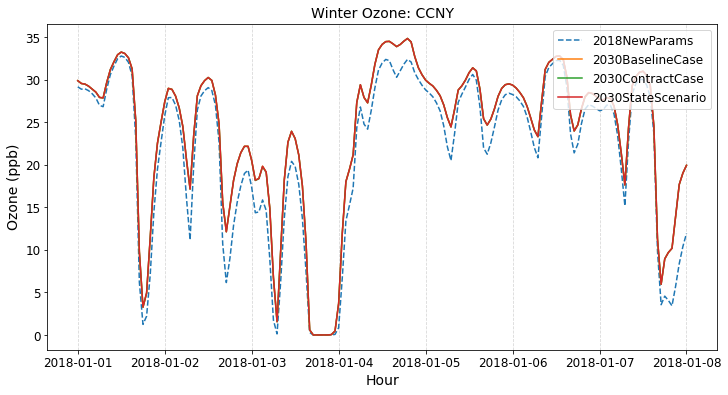

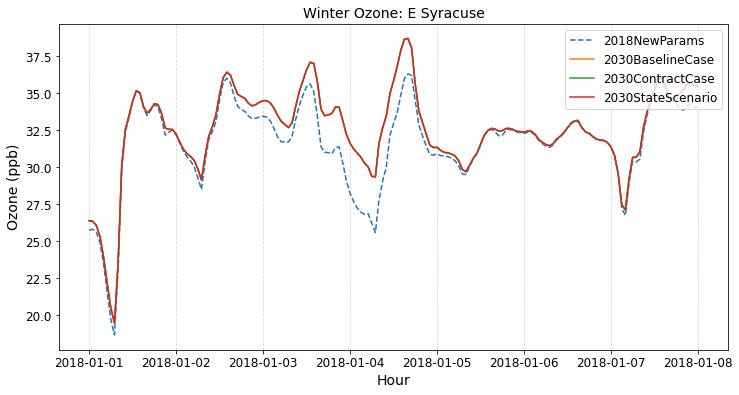

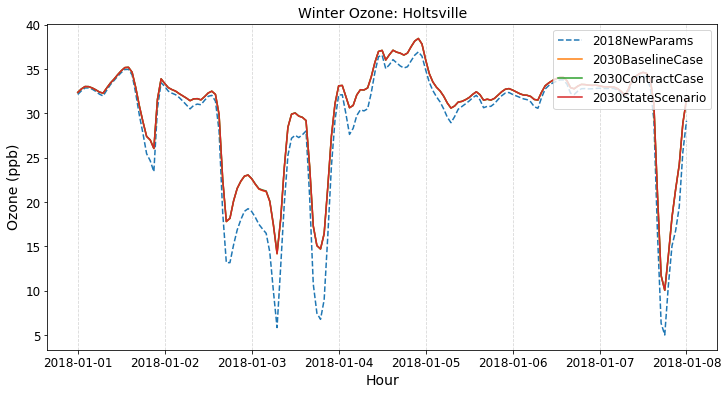

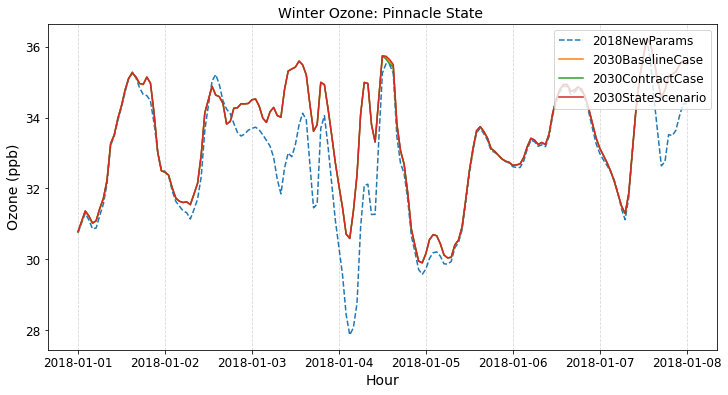

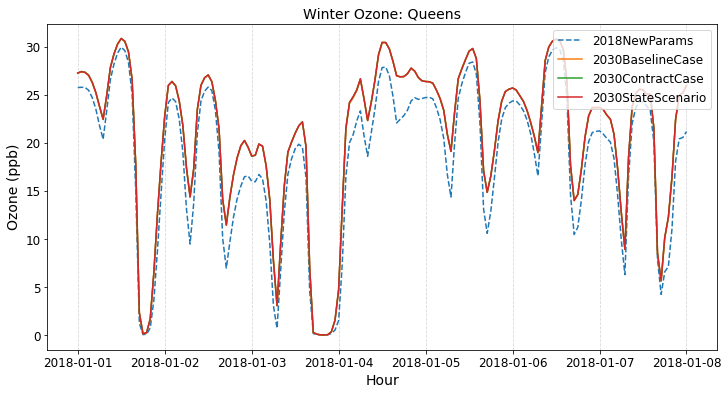

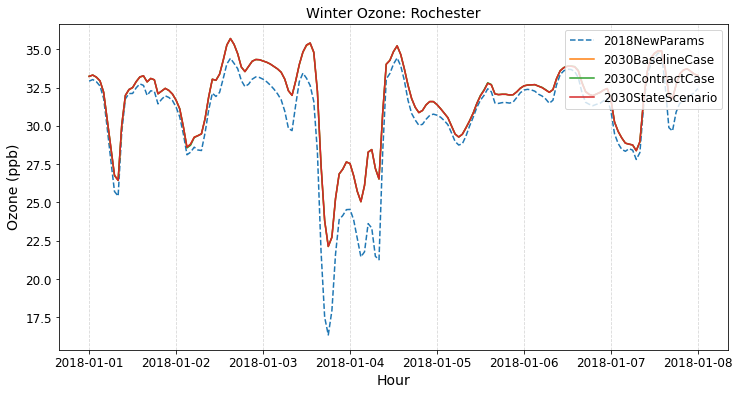

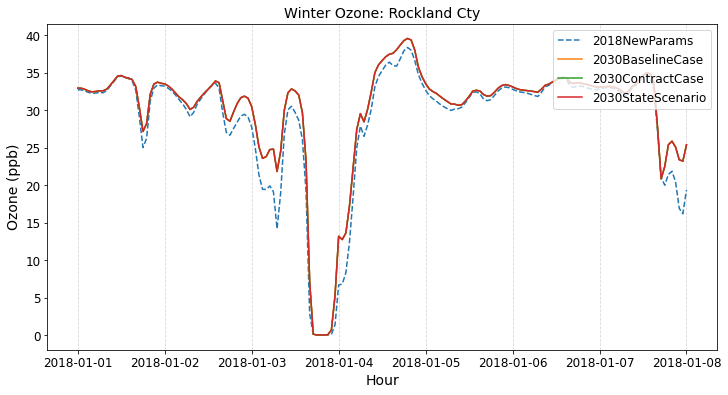

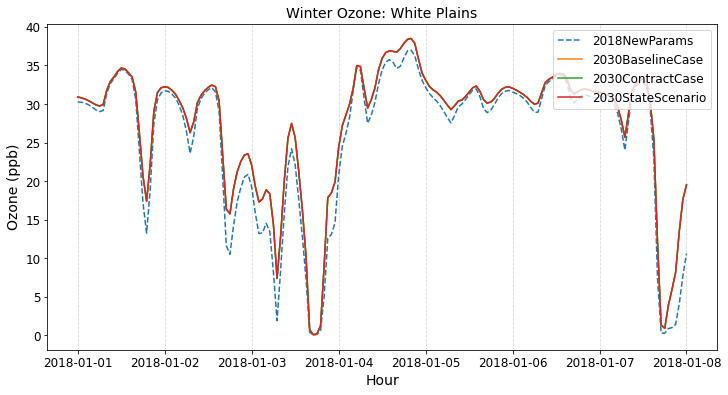

In [25]:
for site_name in site_names:
    fig, ax = plot_site_comparison(
        # airnow_winter_site_data['O3'][site_name],
        # cmaq_winter_site_data_2018['O3'][site_name],
        # cmaq_winter_site_data_2032['O3'][site_name],
        cmaq_nygrid_site_data_1=cmaq_winter_nygrid_site_data_2018['O3'][site_name],
        cmaq_nygrid_site_data_2=cmaq_winter_nygrid_site_data_2030BaselineCase['O3'][site_name],
        cmaq_nygrid_site_data_3=cmaq_winter_nygrid_site_data_2030ContractCase['O3'][site_name],
        cmaq_nygrid_site_data_4=cmaq_winter_nygrid_site_data_2030StateScenario[
            'O3'][site_name],
        start_date=winter_sim_2018['start_date'],
        end_date=winter_sim_2018['end_date'],
        title=f'Winter Ozone: {site_name}',
        xlabel='Hour',
        ylabel='Ozone (ppb)',
        fontsize=12
    )

### 2.2. Summer Ozone

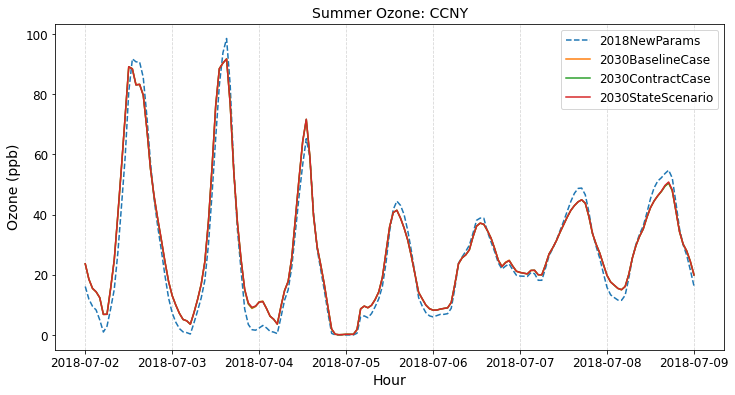

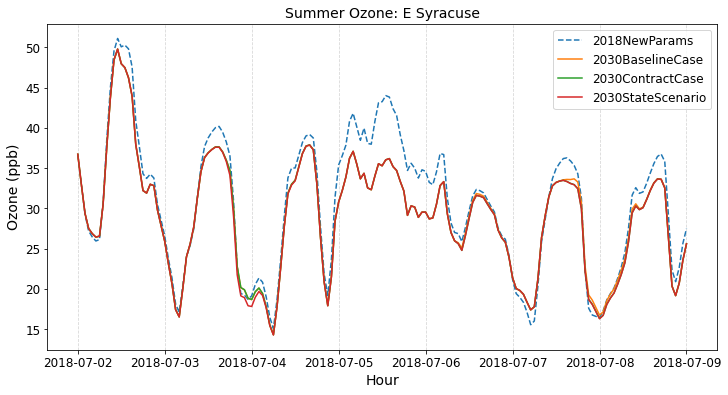

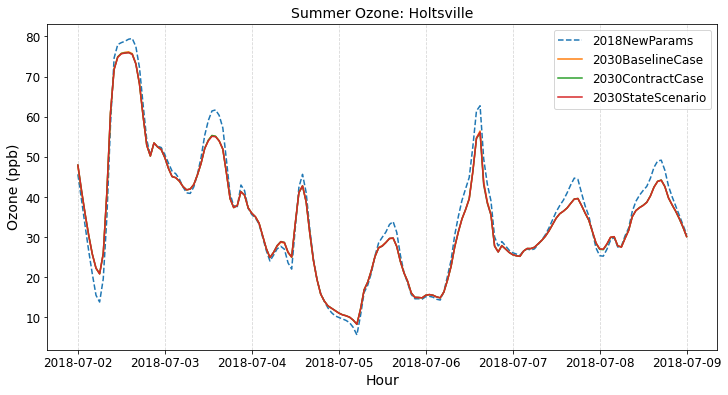

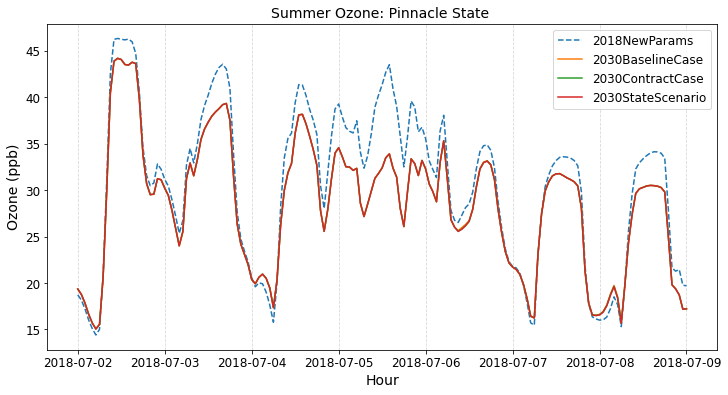

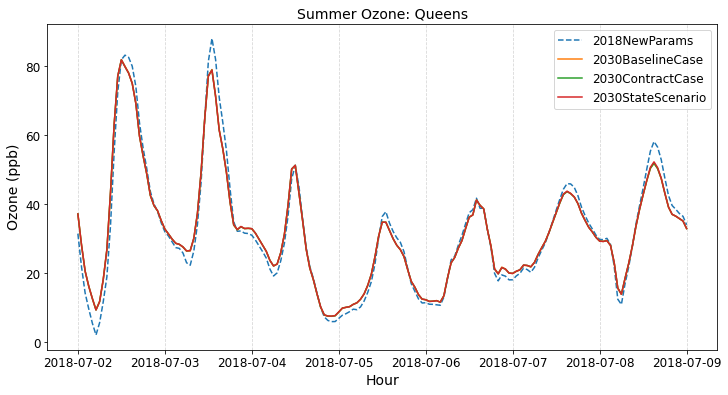

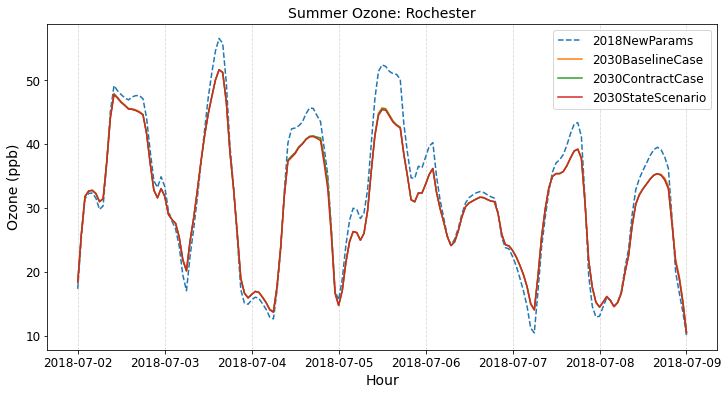

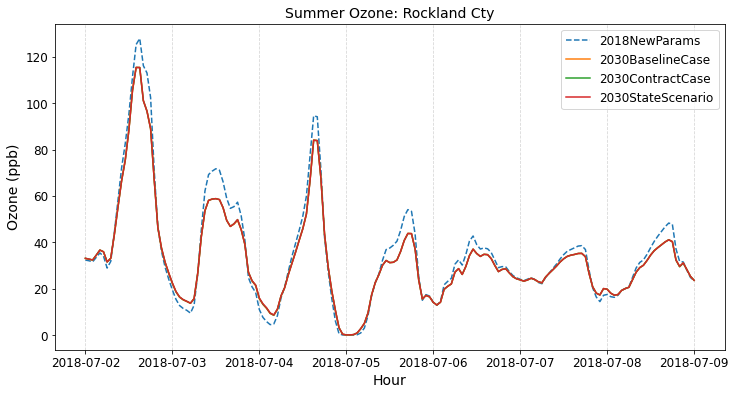

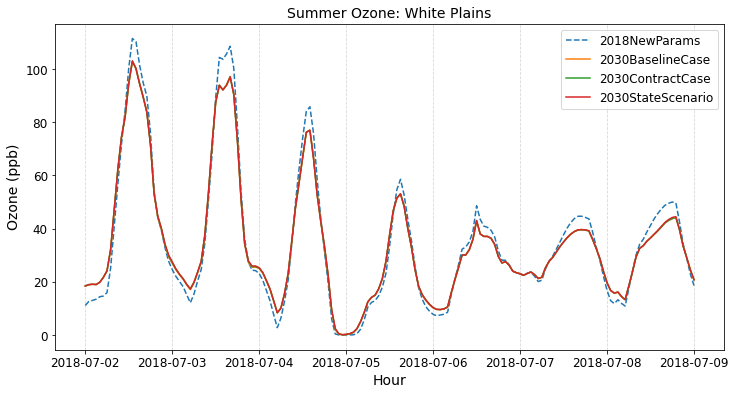

In [26]:
for site_name in site_names:
    fig, ax = plot_site_comparison(
        # airnow_summer_site_data['O3'][site_name],
        # cmaq_summer_site_data_2018['O3'][site_name],
        # cmaq_summer_site_data_2032['O3'][site_name],
        cmaq_nygrid_site_data_1=cmaq_summer_nygrid_site_data_2018['O3'][site_name],
        cmaq_nygrid_site_data_2=cmaq_summer_nygrid_site_data_2030BaselineCase['O3'][site_name],
        cmaq_nygrid_site_data_3=cmaq_summer_nygrid_site_data_2030ContractCase['O3'][site_name],
        cmaq_nygrid_site_data_4=cmaq_summer_nygrid_site_data_2030StateScenario[
            'O3'][site_name],
        start_date=summer_sim_2018['start_date'],
        end_date=summer_sim_2018['end_date'],
        title=f'Summer Ozone: {site_name}',
        xlabel='Hour',
        ylabel='Ozone (ppb)',
        fontsize=12
    )

## 2. Maps

In [27]:
import cartopy

bottom_left_lon = -85.0
top_right_lon = -65.0
bottom_left_lat = 38.0
top_right_lat = 48.0

closer_bounds = ccrs.transform_points(cartopy.crs.PlateCarree(),
                                      np.array([bottom_left_lon, top_right_lon]),
                                      np.array([bottom_left_lat, top_right_lat]))

### 1.1. Winter PM2.5

In [28]:
# Get the plot variables
# EPA Baseline
pm25_winter_mean_base_2018 = conc_winter_base_2018['PM25'].mean(
    dim='time').squeeze()
pm25_winter_mean_base_2032 = conc_winter_base_2032['PM25'].mean(
    dim='time').squeeze()

pm25_winter_mean_diff_base_2032_2018 = (conc_winter_base_2032['PM25']
                                        - conc_winter_base_2018['PM25']).mean(dim='time').squeeze()
pm25_winter_mean_pct_diff_base_2032_2018 = ((conc_winter_base_2032['PM25']
                                             - conc_winter_base_2018['PM25'])
                                            / conc_winter_base_2018['PM25'] * 100).mean(dim='time').squeeze()

# NYGrid scenarios
pm25_winter_mean_nygrid_2018 = conc_winter_nygrid_2018['PM25'].mean(
    dim='time').squeeze()

# 1) 2030BaselineCase
pm25_winter_mean_nygrid_2030BaselineCase = conc_winter_nygrid_2030BaselineCase['PM25'].mean(
    dim='time').squeeze()
pm25_winter_mean_diff_nygrid_2030BaselineCase = (conc_winter_nygrid_2030BaselineCase['PM25']
                                                 - conc_winter_nygrid_2018['PM25']).mean(dim='time').squeeze()
pm25_winter_mean_pct_diff_nygrid_2030BaselineCase = ((conc_winter_nygrid_2030BaselineCase['PM25']
                                                      - conc_winter_nygrid_2018['PM25'])
                                                     / conc_winter_nygrid_2018['PM25'] * 100).mean(dim='time').squeeze()

# 2) 2030ContractCase
pm25_winter_mean_nygrid_2030ContractCase = conc_winter_nygrid_2030ContractCase['PM25'].mean(
    dim='time').squeeze()
pm25_winter_mean_diff_nygrid_2030ContractCase = (conc_winter_nygrid_2030ContractCase['PM25']
                                                 - conc_winter_nygrid_2018['PM25']).mean(dim='time').squeeze()
pm25_winter_mean_pct_diff_nygrid_2030ContractCase = ((conc_winter_nygrid_2030ContractCase['PM25']
                                                      - conc_winter_nygrid_2018['PM25'])
                                                     / conc_winter_nygrid_2018['PM25'] * 100).mean(dim='time').squeeze()


# 3) 2030StateScenario
pm25_winter_mean_nygrid_2030StateScenario = conc_winter_nygrid_2030StateScenario['PM25'].mean(
    dim='time').squeeze()
pm25_winter_mean_diff_nygrid_2030StateScenario = (conc_winter_nygrid_2030StateScenario['PM25']
                                                  - conc_winter_nygrid_2018['PM25']).mean(dim='time').squeeze()
pm25_winter_mean_pct_diff_nygrid_2030StateScenario = ((conc_winter_nygrid_2030StateScenario['PM25']
                                                       - conc_winter_nygrid_2018['PM25'])
                                                      / conc_winter_nygrid_2018['PM25'] * 100).mean(dim='time').squeeze()

# 4) Comparison between policy scenarios
pm25_winter_mean_diff_nygrid_2030CC_2030BC = (conc_winter_nygrid_2030ContractCase['PM25']
                                                - conc_winter_nygrid_2030BaselineCase['PM25']).mean(dim='time').squeeze()
pm25_winter_mean_pct_diff_nygrid_2030CC_2030BC = ((conc_winter_nygrid_2030ContractCase['PM25']
                                                   - conc_winter_nygrid_2030BaselineCase['PM25'])
                                                  / conc_winter_nygrid_2030BaselineCase['PM25'] * 100).mean(dim='time').squeeze()

pm25_winter_mean_diff_nygrid_2030SS_2030BC = (conc_winter_nygrid_2030StateScenario['PM25']
                                                - conc_winter_nygrid_2030BaselineCase['PM25']).mean(dim='time').squeeze()
pm25_winter_mean_pct_diff_nygrid_2030SS_2030BC = ((conc_winter_nygrid_2030StateScenario['PM25']
                                                   - conc_winter_nygrid_2030BaselineCase['PM25'])
                                                  / conc_winter_nygrid_2030BaselineCase['PM25'] * 100).mean(dim='time').squeeze()

pm25_winter_mean_diff_nygrid_2030SS_2030CC = (conc_winter_nygrid_2030StateScenario['PM25']
                                                - conc_winter_nygrid_2030ContractCase['PM25']).mean(dim='time').squeeze()
pm25_winter_mean_pct_diff_nygrid_2030SS_2030CC = ((conc_winter_nygrid_2030StateScenario['PM25']
                                                   - conc_winter_nygrid_2030ContractCase['PM25'])
                                                  / conc_winter_nygrid_2030ContractCase['PM25'] * 100).mean(dim='time').squeeze()

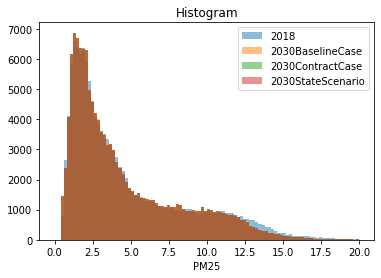

In [29]:
# pm25_winter_mean_base_2018.plot.hist(bins=100, range=(0, 20), label='Base 2018', alpha=0.5)
# pm25_winter_mean_base_2032.plot.hist(bins=100, range=(0, 20), label='Base 2032', alpha=0.5)
pm25_winter_mean_nygrid_2018.plot.hist(
    bins=100, range=(0, 20), label='2018', alpha=0.5)
pm25_winter_mean_nygrid_2030BaselineCase.plot.hist(
    bins=100, range=(0, 20), label='2030BaselineCase', alpha=0.5)
pm25_winter_mean_nygrid_2030ContractCase.plot.hist(
    bins=100, range=(0, 20), label='2030ContractCase', alpha=0.5)
pm25_winter_mean_nygrid_2030StateScenario.plot.hist(
    bins=100, range=(0, 20), label='2030StateScenario', alpha=0.5)
plt.legend()
plt.show()

/home/by276/anaconda3/envs/optwrf_new/lib/python3.7/site-packages/cartopy/mpl/geoaxes.py:1598: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  shading=shading)


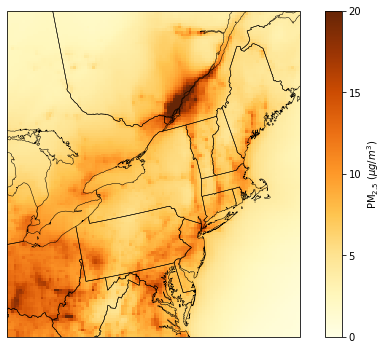

In [30]:
# NYGrid 2018 winter PM2.5 mean
plots.conc_map(
    pm25_winter_mean_nygrid_2018, cmap=cm.get_cmap('YlOrBr'),
    figsize=(9, 6), ax=None,
    cartopy_crs=ccrs,
    #    proj_bounds=proj_bounds,
    proj_bounds=closer_bounds,
    vmin=0, vmax=20,
    cbar_args={
        "cbar_ticks": [0, 5, 10, 15, 20],
        "cbar_label": 'PM$_{2.5}$ ($\mu g/m^{3}$)'
    },
    savefig=True,
    figpath='../data/plots/winter_pm25_mean_nygrid_2018NewParams.png'
)

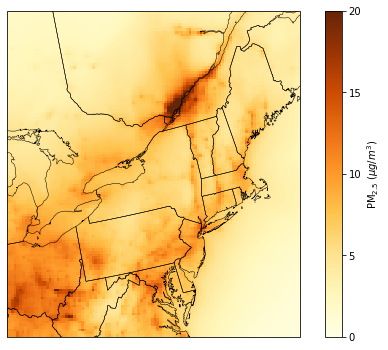

In [31]:
# NYGrid 2030BaselineCase winter PM2.5 mean
plots.conc_map(
    pm25_winter_mean_nygrid_2030BaselineCase, cmap=cm.get_cmap('YlOrBr'),
    figsize=(9, 6), ax=None,
    cartopy_crs=ccrs,
    #    proj_bounds=proj_bounds,
    proj_bounds=closer_bounds,
    vmin=0, vmax=20,
    cbar_args={
        "cbar_ticks": [0, 5, 10, 15, 20],
        "cbar_label": 'PM$_{2.5}$ ($\mu g/m^{3}$)'
    },
    savefig=True,
    figpath='../data/plots/winter_pm25_mean_nygrid_2030BaselineCase.png'
)

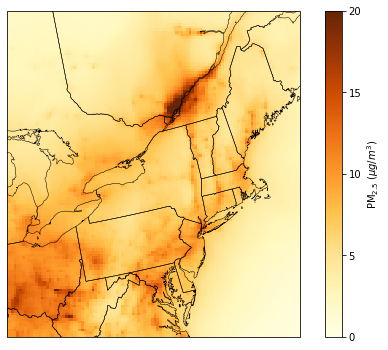

In [32]:
# NYGrid 2030ContractCase winter PM2.5 mean
plots.conc_map(
    pm25_winter_mean_nygrid_2030ContractCase, cmap=cm.get_cmap('YlOrBr'),
    figsize=(9, 6), ax=None,
    cartopy_crs=ccrs,
    #    proj_bounds=proj_bounds,
    proj_bounds=closer_bounds,
    vmin=0, vmax=20,
    cbar_args={
        "cbar_ticks": [0, 5, 10, 15, 20],
        "cbar_label": 'PM$_{2.5}$ ($\mu g/m^{3}$)'
    },
    savefig=True,
    figpath='../data/plots/winter_pm25_mean_nygrid_2030ContractCase.png'
)

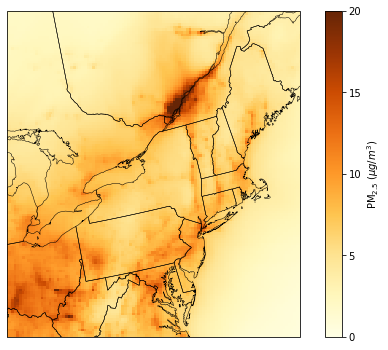

In [33]:
# NYGrid 2030StateScenario winter PM2.5 mean
plots.conc_map(
    pm25_winter_mean_nygrid_2030StateScenario, cmap=cm.get_cmap('YlOrBr'),
    figsize=(9, 6), ax=None,
    cartopy_crs=ccrs,
    #    proj_bounds=proj_bounds,
    proj_bounds=closer_bounds,
    vmin=0, vmax=20,
    cbar_args={
        "cbar_ticks": [0, 5, 10, 15, 20],
        "cbar_label": 'PM$_{2.5}$ ($\mu g/m^{3}$)'
    },
    savefig=True,
    figpath='../data/plots/winter_pm25_mean_nygrid_2030StateScenario.png'
)

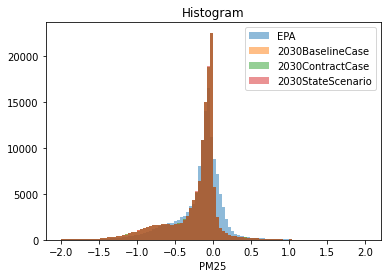

In [34]:
pm25_winter_mean_diff_base_2032_2018.plot.hist(
    bins=100, range=(-2, 2), label='EPA', alpha=0.5)
pm25_winter_mean_diff_nygrid_2030BaselineCase.plot.hist(
    bins=100, range=(-2, 2), label='2030BaselineCase', alpha=0.5)
pm25_winter_mean_diff_nygrid_2030ContractCase.plot.hist(
    bins=100, range=(-2, 2), label='2030ContractCase', alpha=0.5)
pm25_winter_mean_diff_nygrid_2030StateScenario.plot.hist(
    bins=100, range=(-2, 2), label='2030StateScenario', alpha=0.5)
plt.legend()
plt.show()

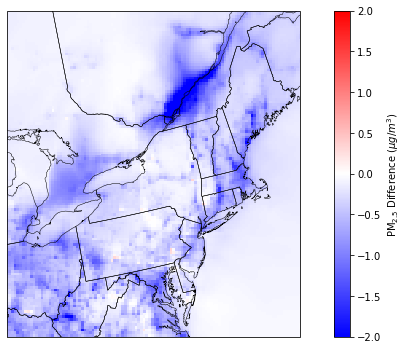

In [35]:
# EPA 2032 - 2018 winter PM2.5 difference mean
plots.conc_map(
    pm25_winter_mean_diff_base_2032_2018,
    cmap=cm.get_cmap('bwr'),
    figsize=(12, 6), ax=None,
    cartopy_crs=ccrs,
    #    proj_bounds=proj_bounds,
    proj_bounds=closer_bounds,
    vmin=-2, vmax=2,
    cbar_args={
        "cbar_ticks": [-2, -1.5, -1, -0.5, 0, 0.5, 1, 1.5, 2],
        "cbar_label": 'PM$_{2.5}$ Difference ($\mu g/m^{3}$)',
    },
    savefig=True,
    figpath='../data/plots/winter_pm25_diff_mean_EPA.png'
)

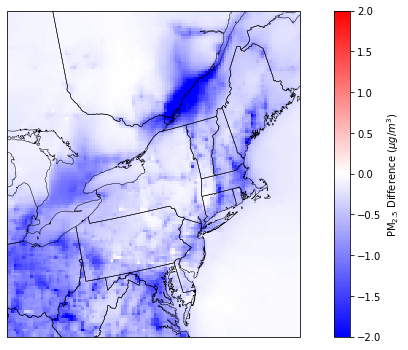

In [36]:
# NYGrid 2030BaselineCase - 2018 winter PM2.5 difference mean
plots.conc_map(
    pm25_winter_mean_diff_nygrid_2030BaselineCase,
    cmap=cm.get_cmap('bwr'),
    figsize=(12, 6),
    ax=None,
    cartopy_crs=ccrs,
    #    proj_bounds=proj_bounds,
    proj_bounds=closer_bounds,
    vmin=-2,
    vmax=2,
    cbar_args={
        "cbar_ticks": [-2, -1.5, -1, -0.5, 0, 0.5, 1, 1.5, 2],
        "cbar_label": 'PM$_{2.5}$ Difference ($\mu g/m^{3}$)',
    },
    savefig=True,
    figpath='../data/plots/winter_pm25_diff_mean_2030BaselineCase.png'
)

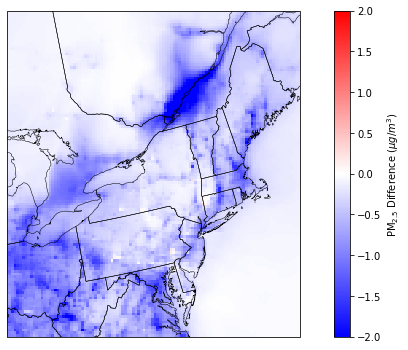

In [37]:
# NYGrid 2030ContractCase - 2018 winter PM2.5 difference mean
plots.conc_map(
    pm25_winter_mean_diff_nygrid_2030ContractCase,
    cmap=cm.get_cmap('bwr'),
    figsize=(12, 6),
    ax=None,
    cartopy_crs=ccrs,
    #    proj_bounds=proj_bounds,
    proj_bounds=closer_bounds,
    vmin=-2,
    vmax=2,
    cbar_args={
        "cbar_ticks": [-2, -1.5, -1, -0.5, 0, 0.5, 1, 1.5, 2],
        "cbar_label": 'PM$_{2.5}$ Difference ($\mu g/m^{3}$)',
    },
    savefig=True,
    figpath='../data/plots/winter_pm25_diff_mean_2030ContractCase.png'
)

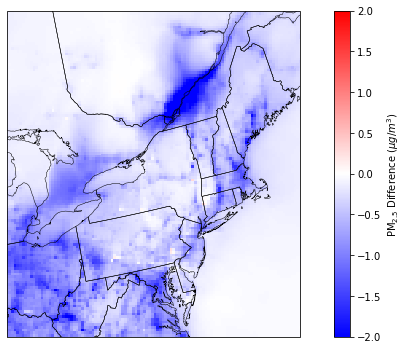

In [38]:
# NYGrid 2030StateScenario - 2018 winter PM2.5 difference mean
plots.conc_map(
    pm25_winter_mean_diff_nygrid_2030StateScenario,
    cmap=cm.get_cmap('bwr'),
    figsize=(12, 6),
    ax=None,
    cartopy_crs=ccrs,
    #    proj_bounds=proj_bounds,
    proj_bounds=closer_bounds,
    vmin=-2,
    vmax=2,
    cbar_args={
        "cbar_ticks": [-2, -1.5, -1, -0.5, 0, 0.5, 1, 1.5, 2],
        "cbar_label": 'PM$_{2.5}$ Difference ($\mu g/m^{3}$)',
    },
    savefig=True,
    figpath='../data/plots/winter_pm25_diff_mean_2030StateScenario.png'
)

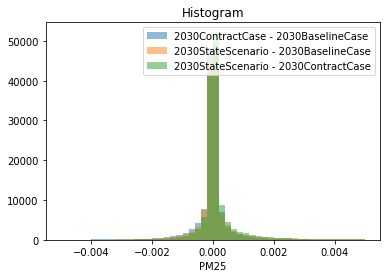

In [39]:
pm25_winter_mean_diff_nygrid_2030CC_2030BC.plot.hist(
    bins=50, range=(-0.005, 0.005), label='2030ContractCase - 2030BaselineCase', alpha=0.5)
pm25_winter_mean_diff_nygrid_2030SS_2030BC.plot.hist(
    bins=50, range=(-0.005, 0.005), label='2030StateScenario - 2030BaselineCase', alpha=0.5)
pm25_winter_mean_diff_nygrid_2030SS_2030CC.plot.hist(
    bins=50, range=(-0.005, 0.005), label='2030StateScenario - 2030ContractCase', alpha=0.5)
plt.legend()
plt.show()

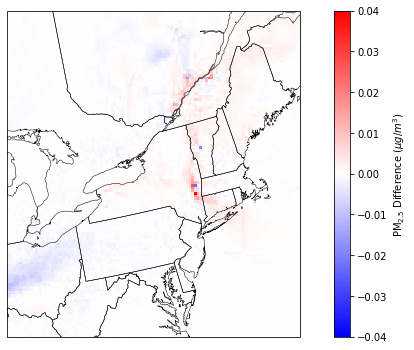

In [40]:
# NYGrid 2030ContractCase - 2030BaselineCase winter PM2.5 percentage difference mean
plots.conc_map(
    pm25_winter_mean_diff_nygrid_2030CC_2030BC,
    cmap=cm.get_cmap('bwr'),
    figsize=(12, 6),
    ax=None,
    cartopy_crs=ccrs,
    #    proj_bounds=proj_bounds,
    proj_bounds=closer_bounds,
    vmin=-0.04,
    vmax=0.04,
    cbar_args={
        "cbar_ticks": [-0.04, -0.03, -0.02, -0.01, 0, 0.01, 0.02, 0.03, 0.04],
        "cbar_label": 'PM$_{2.5}$ Difference ($\mu g/m^{3}$)',
    },
    savefig=True,
    figpath='../data/plots/winter_pm25_diff_mean_2030CC_2030BC.png'
)

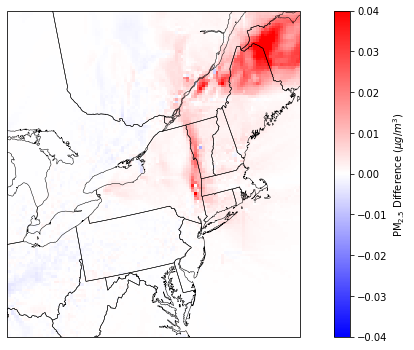

In [41]:
# NYGrid 2030StateScenario - 2030BaselineCase winter PM2.5 percentage difference mean
plots.conc_map(
    pm25_winter_mean_diff_nygrid_2030SS_2030BC,
    cmap=cm.get_cmap('bwr'),
    figsize=(12, 6),
    ax=None,
    cartopy_crs=ccrs,
    #    proj_bounds=proj_bounds,
    proj_bounds=closer_bounds,
    vmin=-0.04,
    vmax=0.04,
    cbar_args={
        "cbar_ticks": [-0.04, -0.03, -0.02, -0.01, 0, 0.01, 0.02, 0.03, 0.04],
        "cbar_label": 'PM$_{2.5}$ Difference ($\mu g/m^{3}$)',
    },
    savefig=True,
    figpath='../data/plots/winter_pm25_diff_mean_2030SS_2030BC.png'
)

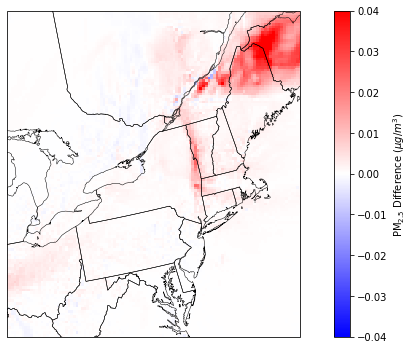

In [42]:
# NYGrid 2030StateScenario - 2030ContractCase winter PM2.5 percentage difference mean
plots.conc_map(
    pm25_winter_mean_diff_nygrid_2030SS_2030CC,
    cmap=cm.get_cmap('bwr'),
    figsize=(12, 6),
    ax=None,
    cartopy_crs=ccrs,
    #    proj_bounds=proj_bounds,
    proj_bounds=closer_bounds,
    vmin=-0.04,
    vmax=0.04,
    cbar_args={
        "cbar_ticks": [-0.04, -0.03, -0.02, -0.01, 0, 0.01, 0.02, 0.03, 0.04],
        "cbar_label": 'PM$_{2.5}$ Difference ($\mu g/m^{3}$)',
    },
    savefig=True,
    figpath='../data/plots/winter_pm25_diff_mean_2030SS_2030CC.png'
)

### 1.2. Summer PM2.5

In [43]:
# Get the plot variables
# EPA Baseline
pm25_summer_mean_base_2018 = conc_summer_base_2018['PM25'].mean(
    dim='time').squeeze()
pm25_summer_mean_base_2032 = conc_summer_base_2032['PM25'].mean(
    dim='time').squeeze()

pm25_summer_mean_diff_base_2032_2018 = (conc_summer_base_2032['PM25']
                                        - conc_summer_base_2018['PM25']).mean(dim='time').squeeze()
pm25_summer_mean_pct_diff_base_2032_2018 = ((conc_winter_base_2032['PM25']
                                             - conc_summer_base_2018['PM25'])
                                            / conc_summer_base_2018['PM25'] * 100).mean(dim='time').squeeze()

# NYGrid scenarios
pm25_summer_mean_nygrid_2018 = conc_summer_nygrid_2018['PM25'].mean(
    dim='time').squeeze()

# 1) 2030BaselineCase
pm25_summer_mean_nygrid_2030BaselineCase = conc_summer_nygrid_2030BaselineCase['PM25'].mean(
    dim='time').squeeze()
pm25_summer_mean_diff_nygrid_2030BaselineCase = (conc_summer_nygrid_2030BaselineCase['PM25']
                                                 - conc_summer_nygrid_2018['PM25']).mean(dim='time').squeeze()
pm25_summer_mean_pct_diff_nygrid_2030BaselineCase = ((conc_summer_nygrid_2030BaselineCase['PM25']
                                                      - conc_summer_nygrid_2018['PM25'])
                                                     / conc_summer_nygrid_2018['PM25'] * 100).mean(dim='time').squeeze()

# 2) 2030ContractCase
pm25_summer_mean_nygrid_2030ContractCase = conc_summer_nygrid_2030ContractCase['PM25'].mean(
    dim='time').squeeze()
pm25_summer_mean_diff_nygrid_2030ContractCase = (conc_summer_nygrid_2030ContractCase['PM25']
                                                 - conc_summer_nygrid_2018['PM25']).mean(dim='time').squeeze()
pm25_summer_mean_pct_diff_nygrid_2030ContractCase = ((conc_summer_nygrid_2030ContractCase['PM25']
                                                      - conc_summer_nygrid_2018['PM25'])
                                                     / conc_summer_nygrid_2018['PM25'] * 100).mean(dim='time').squeeze()

# 3) 2030StateScenario
pm25_summer_mean_nygrid_2030StateScenario = conc_summer_nygrid_2030StateScenario['PM25'].mean(
    dim='time').squeeze()
pm25_summer_mean_diff_nygrid_2030StateScenario = (conc_summer_nygrid_2030StateScenario['PM25']
                                                  - conc_summer_nygrid_2018['PM25']).mean(dim='time').squeeze()
pm25_summer_mean_pct_diff_nygrid_2030StateScenario = ((conc_summer_nygrid_2030StateScenario['PM25']
                                                       - conc_summer_nygrid_2018['PM25'])
                                                      / conc_summer_nygrid_2018['PM25'] * 100).mean(dim='time').squeeze()

# 4) Comparison between policy scenarios
pm25_summer_mean_diff_nygrid_2030CC_2030BC = (conc_summer_nygrid_2030ContractCase['PM25']
                                                - conc_summer_nygrid_2030BaselineCase['PM25']).mean(dim='time').squeeze()
pm25_summer_mean_pct_diff_nygrid_2030CC_2030BC = ((conc_summer_nygrid_2030ContractCase['PM25']
                                                   - conc_summer_nygrid_2030BaselineCase['PM25'])
                                                  / conc_summer_nygrid_2030BaselineCase['PM25'] * 100).mean(dim='time').squeeze()

pm25_summer_mean_diff_nygrid_2030SS_2030BC = (conc_summer_nygrid_2030StateScenario['PM25']
                                                - conc_summer_nygrid_2030BaselineCase['PM25']).mean(dim='time').squeeze()
pm25_summer_mean_pct_diff_nygrid_2030SS_2030BC = ((conc_summer_nygrid_2030StateScenario['PM25']
                                                    - conc_summer_nygrid_2030BaselineCase['PM25'])
                                                      / conc_summer_nygrid_2030BaselineCase['PM25'] * 100).mean(dim='time').squeeze()

pm25_summer_mean_diff_nygrid_2030SS_2030CC = (conc_summer_nygrid_2030StateScenario['PM25']
                                                - conc_summer_nygrid_2030ContractCase['PM25']).mean(dim='time').squeeze()
pm25_summer_mean_pct_diff_nygrid_2030SS_2030CC = ((conc_summer_nygrid_2030StateScenario['PM25']
                                                    - conc_summer_nygrid_2030ContractCase['PM25'])
                                                      / conc_summer_nygrid_2030ContractCase['PM25'] * 100).mean(dim='time').squeeze()


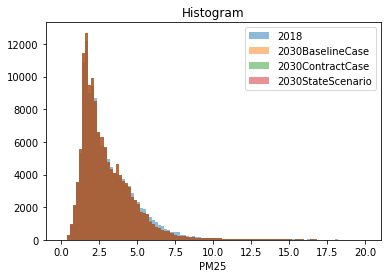

In [44]:
# pm25_summer_mean_base_2018.plot.hist(bins=100, range=(0, 20), label='Base 2018', alpha=0.5)
# pm25_summer_mean_base_2032.plot.hist(bins=100, range=(0, 20), label='Base 2032', alpha=0.5)
pm25_summer_mean_nygrid_2018.plot.hist(
    bins=100, range=(0, 20), label='2018', alpha=0.5)
pm25_summer_mean_nygrid_2030BaselineCase.plot.hist(
    bins=100, range=(0, 20), label='2030BaselineCase', alpha=0.5)
pm25_summer_mean_nygrid_2030ContractCase.plot.hist(
    bins=100, range=(0, 20), label='2030ContractCase', alpha=0.5)
pm25_summer_mean_nygrid_2030StateScenario.plot.hist(
    bins=100, range=(0, 20), label='2030StateScenario', alpha=0.5)
plt.legend()
plt.show()

/home/by276/anaconda3/envs/optwrf_new/lib/python3.7/site-packages/cartopy/mpl/geoaxes.py:1598: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  shading=shading)


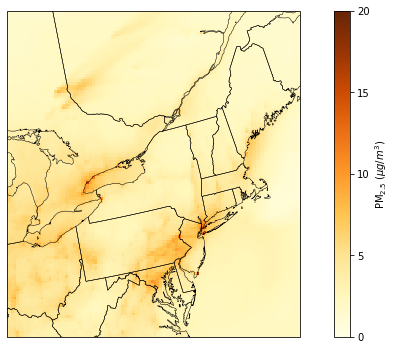

In [45]:
# NYGrid 2018 summer PM2.5 mean
plots.conc_map(pm25_summer_mean_nygrid_2018, cmap=cm.get_cmap('YlOrBr'),
               figsize=(12, 6), ax=None,
               cartopy_crs=ccrs,
               #    proj_bounds=proj_bounds,
               proj_bounds=closer_bounds,
               vmin=0, vmax=20,
               cbar_args={
                   "cbar_ticks": [0, 5, 10, 15, 20],
    "cbar_label": 'PM$_{2.5}$ ($\mu g/m^{3}$)'
},
    savefig=True,
    figpath='../data/plots/winter_pm25_mean_2018NewParams.png')

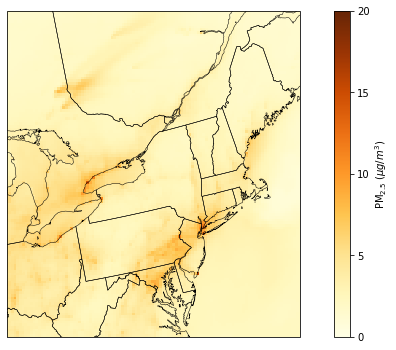

In [46]:
# NYGrid 2030BaselineCase summer PM2.5 mean
plots.conc_map(
    pm25_summer_mean_nygrid_2030BaselineCase, cmap=cm.get_cmap('YlOrBr'),
    figsize=(12, 6), ax=None,
    cartopy_crs=ccrs,
    #    proj_bounds=proj_bounds,
    proj_bounds=closer_bounds,
    vmin=0, vmax=20,
    cbar_args={
        "cbar_ticks": [0, 5, 10, 15, 20],
        "cbar_label": 'PM$_{2.5}$ ($\mu g/m^{3}$)'
    },
    savefig=True,
    figpath='../data/plots/winter_pm25_mean_2030BaselineCase.png')

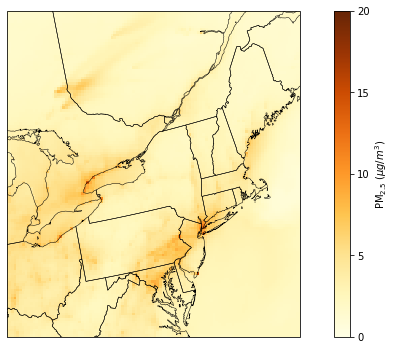

In [47]:
# NYGrid 2030ContractCase summer PM2.5 mean
plots.conc_map(
    pm25_summer_mean_nygrid_2030ContractCase, cmap=cm.get_cmap('YlOrBr'),
    figsize=(12, 6), ax=None,
    cartopy_crs=ccrs,
    #    proj_bounds=proj_bounds,
    proj_bounds=closer_bounds,
    vmin=0, vmax=20,
    cbar_args={
        "cbar_ticks": [0, 5, 10, 15, 20],
        "cbar_label": 'PM$_{2.5}$ ($\mu g/m^{3}$)'
    },
    savefig=True,
    figpath='../data/plots/winter_pm25_mean_2030ContractCase.png')

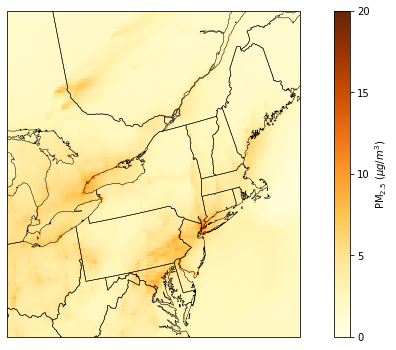

In [48]:
# NYGrid 2030StateScenario summer PM2.5 mean
plots.conc_map(
    pm25_summer_mean_nygrid_2030StateScenario, cmap=cm.get_cmap('YlOrBr'),
    figsize=(12, 6), ax=None,
    cartopy_crs=ccrs,
    #    proj_bounds=proj_bounds,
    proj_bounds=closer_bounds,
    vmin=0, vmax=20,
    cbar_args={
        "cbar_ticks": [0, 5, 10, 15, 20],
    "cbar_label": 'PM$_{2.5}$ ($\mu g/m^{3}$)'
    },
    savefig=True,
    figpath='../data/plots/winter_pm25_mean_2030StateScenario.png')

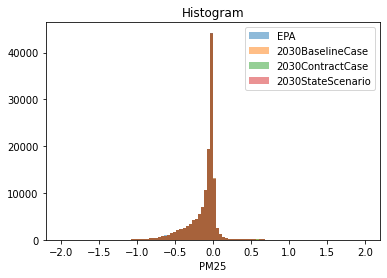

In [49]:
pm25_summer_mean_diff_base_2032_2018.plot.hist(
    bins=100, range=(-2, 2), label='EPA', alpha=0.5)
pm25_summer_mean_diff_nygrid_2030BaselineCase.plot.hist(
    bins=100, range=(-2, 2), label='2030BaselineCase', alpha=0.5)
pm25_summer_mean_diff_nygrid_2030ContractCase.plot.hist(
    bins=100, range=(-2, 2), label='2030ContractCase', alpha=0.5)
pm25_summer_mean_diff_nygrid_2030StateScenario.plot.hist(
    bins=100, range=(-2, 2), label='2030StateScenario', alpha=0.5)
plt.legend()
plt.show()

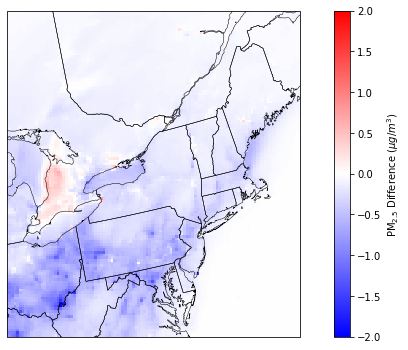

In [50]:
# EPA 2032 - 2018 summer PM2.5 difference mean
plots.conc_map(pm25_summer_mean_diff_base_2032_2018,
               cmap=cm.get_cmap('bwr'),
               figsize=(12, 6),
               ax=None,
               cartopy_crs=ccrs,
               #    proj_bounds=proj_bounds,
               proj_bounds=closer_bounds,
               vmin=-2,
               vmax=2,
               cbar_args={
                   "cbar_ticks": [-2, -1.5, -1, -0.5, 0, 0.5, 1, 1.5, 2],
                   "cbar_label": 'PM$_{2.5}$ Difference ($\mu g/m^{3}$)',
               },
               savefig=True,
               figpath='../data/plots/winter_pm25_diff_mean_EPA.png')

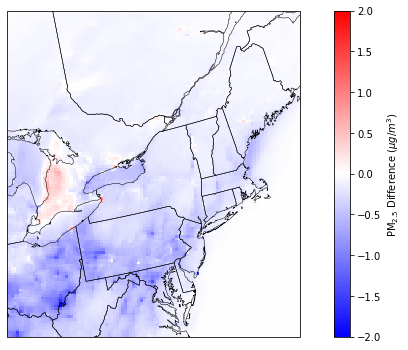

In [51]:
# NYGrid 2030BaselineCase - 2018 summer PM2.5 difference mean
plots.conc_map(pm25_summer_mean_diff_nygrid_2030BaselineCase,
               cmap=cm.get_cmap('bwr'),
               figsize=(12, 6),
               ax=None,
               cartopy_crs=ccrs,
               #    proj_bounds=proj_bounds,
               proj_bounds=closer_bounds,
               vmin=-2,
               vmax=2,
               cbar_args={
                   "cbar_ticks": [-2, -1.5, -1, -0.5, 0, 0.5, 1, 1.5, 2],
                   "cbar_label": 'PM$_{2.5}$ Difference ($\mu g/m^{3}$)',
               },
               savefig=True,
               figpath='../data/plots/winter_pm25_diff_mean_2030BaselineCase.png')

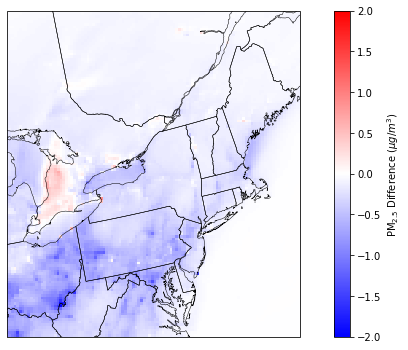

In [52]:
# NYGrid 2030ContractCase - 2018 summer PM2.5 difference mean
plots.conc_map(pm25_summer_mean_diff_nygrid_2030ContractCase,
               cmap=cm.get_cmap('bwr'),
               figsize=(12, 6),
               ax=None,
               cartopy_crs=ccrs,
               #    proj_bounds=proj_bounds,
               proj_bounds=closer_bounds,
               vmin=-2,
               vmax=2,
               cbar_args={
                   "cbar_ticks": [-2, -1.5, -1, -0.5, 0, 0.5, 1, 1.5, 2],
                   "cbar_label": 'PM$_{2.5}$ Difference ($\mu g/m^{3}$)',
               },
               savefig=True,
               figpath='../data/plots/winter_pm25_diff_mean_2030ContractCase.png')

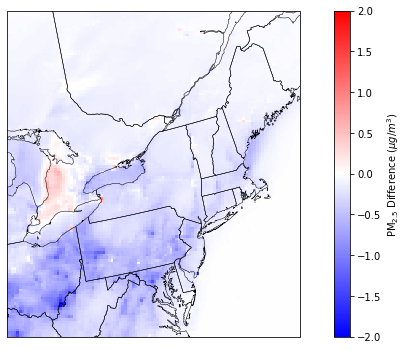

In [53]:
# NYGrid 2030StateScenario - 2018 summer PM2.5 difference mean
plots.conc_map(pm25_summer_mean_diff_nygrid_2030StateScenario,
               cmap=cm.get_cmap('bwr'),
               figsize=(12, 6),
               ax=None,
               cartopy_crs=ccrs,
               #    proj_bounds=proj_bounds,
               proj_bounds=closer_bounds,
               vmin=-2,
               vmax=2,
               cbar_args={
                   "cbar_ticks": [-2, -1.5, -1, -0.5, 0, 0.5, 1, 1.5, 2],
                   "cbar_label": 'PM$_{2.5}$ Difference ($\mu g/m^{3}$)',
               },
               savefig=True,
               figpath='../data/plots/winter_pm25_diff_mean_2030StateScenario.png')

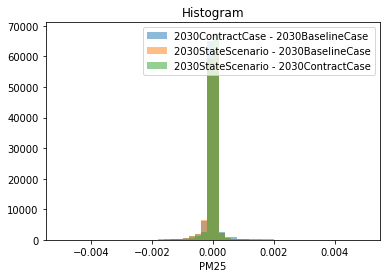

In [54]:
pm25_summer_mean_diff_nygrid_2030CC_2030BC.plot.hist(
    bins=50, range=(-0.005, 0.005), label='2030ContractCase - 2030BaselineCase', alpha=0.5)
pm25_summer_mean_diff_nygrid_2030SS_2030BC.plot.hist(
    bins=50, range=(-0.005, 0.005), label='2030StateScenario - 2030BaselineCase', alpha=0.5)
pm25_summer_mean_diff_nygrid_2030SS_2030CC.plot.hist(
    bins=50, range=(-0.005, 0.005), label='2030StateScenario - 2030ContractCase', alpha=0.5)
plt.legend()
plt.show()

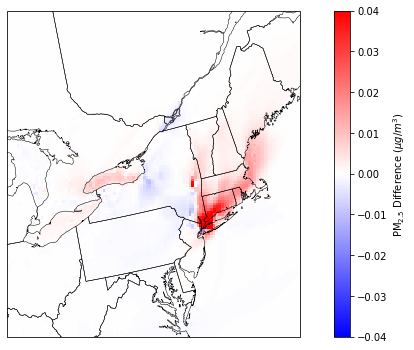

In [55]:
# NYGrid 2030ContractCase - 2030BaselineCase summer PM2.5 percentage difference mean
plots.conc_map(
    pm25_summer_mean_diff_nygrid_2030CC_2030BC,
    cmap=cm.get_cmap('bwr'),
    figsize=(12, 6),
    ax=None,
    cartopy_crs=ccrs,
    #    proj_bounds=proj_bounds,
    proj_bounds=closer_bounds,
    vmin=-0.04,
    vmax=0.04,
    cbar_args={
        "cbar_ticks": [-0.04, -0.03, -0.02, -0.01, 0, 0.01, 0.02, 0.03, 0.04],
        "cbar_label": 'PM$_{2.5}$ Difference ($\mu g/m^{3}$)',
    },
    savefig=True,
    figpath='../data/plots/summer_pm25_diff_mean_2030CC_2030BC.png'
)

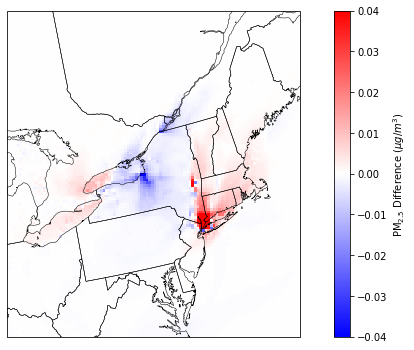

In [56]:
# NYGrid 2030StateScenario - 2030BaselineCase summer PM2.5 percentage difference mean
plots.conc_map(
    pm25_summer_mean_diff_nygrid_2030SS_2030BC,
    cmap=cm.get_cmap('bwr'),
    figsize=(12, 6),
    ax=None,
    cartopy_crs=ccrs,
    #    proj_bounds=proj_bounds,
    proj_bounds=closer_bounds,
    vmin=-0.04,
    vmax=0.04,
    cbar_args={
        "cbar_ticks": [-0.04, -0.03, -0.02, -0.01, 0, 0.01, 0.02, 0.03, 0.04],
        "cbar_label": 'PM$_{2.5}$ Difference ($\mu g/m^{3}$)',
    },
    savefig=True,
    figpath='../data/plots/summer_pm25_diff_mean_2030SS_2030BC.png'
)

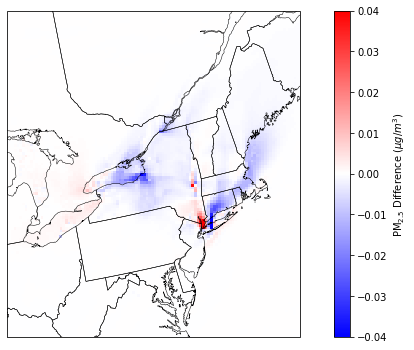

In [57]:
# NYGrid 2030StateScenario - 2030ContractCase summer PM2.5 percentage difference mean
plots.conc_map(
    pm25_summer_mean_diff_nygrid_2030SS_2030CC,
    cmap=cm.get_cmap('bwr'),
    figsize=(12, 6),
    ax=None,
    cartopy_crs=ccrs,
    #    proj_bounds=proj_bounds,
    proj_bounds=closer_bounds,
    vmin=-0.04,
    vmax=0.04,
    cbar_args={
        "cbar_ticks": [-0.04, -0.03, -0.02, -0.01, 0, 0.01, 0.02, 0.03, 0.04],
        "cbar_label": 'PM$_{2.5}$ Difference ($\mu g/m^{3}$)',
    },
    savefig=True,
    figpath='../data/plots/summer_pm25_diff_mean_2030SS_2030CC.png'
)

### 2.1. Winter Ozone

In [58]:
# Get the plot variables
# EPA Baseline
o3_winter_mean_base_2018 = conc_winter_base_2018['O3'].mean(
    dim='time').squeeze()
o3_winter_mean_base_2032 = conc_winter_base_2032['O3'].mean(
    dim='time').squeeze()

o3_winter_mean_diff_base_2032_2018 = (conc_winter_base_2032['O3']
                                      - conc_winter_base_2018['O3']).mean(dim='time').squeeze()
o3_winter_mean_pct_diff_base_2032_2018 = ((conc_winter_base_2032['O3']
                                           - conc_winter_base_2018['O3'])
                                          / conc_winter_base_2018['O3'] * 100).mean(dim='time').squeeze()

# NYGrid scenarios
o3_winter_mean_nygrid_2018 = conc_winter_nygrid_2018['O3'].mean(
    dim='time').squeeze()

# 1) 2030BaselineCase
o3_winter_mean_nygrid_2030BaselineCase = conc_winter_nygrid_2030BaselineCase['O3'].mean(
    dim='time').squeeze()
o3_winter_mean_diff_nygrid_2030BaselineCase = (conc_winter_nygrid_2030BaselineCase['O3']
                                               - conc_winter_nygrid_2018['O3']).mean(dim='time').squeeze()
o3_winter_mean_pct_diff_nygrid_2030BaselineCase = ((conc_winter_nygrid_2030BaselineCase['O3']
                                                    - conc_winter_nygrid_2018['O3'])
                                                   / conc_winter_nygrid_2018['O3'] * 100).mean(dim='time').squeeze()

# 2) 2030ContractCase
o3_winter_mean_nygrid_2030ContractCase = conc_winter_nygrid_2030ContractCase['O3'].mean(
    dim='time').squeeze()
o3_winter_mean_diff_nygrid_2030ContractCase = (conc_winter_nygrid_2030ContractCase['O3']
                                               - conc_winter_nygrid_2018['O3']).mean(dim='time').squeeze()
o3_winter_mean_pct_diff_nygrid_2030ContractCase = ((conc_winter_nygrid_2030ContractCase['O3']
                                                    - conc_winter_nygrid_2018['O3'])
                                                   / conc_winter_nygrid_2018['O3'] * 100).mean(dim='time').squeeze()

# 3) 2030StateScenario
o3_winter_mean_nygrid_2030StateScenario = conc_winter_nygrid_2030StateScenario['O3'].mean(
    dim='time').squeeze()
o3_winter_mean_diff_nygrid_2030StateScenario = (conc_winter_nygrid_2030StateScenario['O3']
                                                - conc_winter_nygrid_2018['O3']).mean(dim='time').squeeze()
o3_winter_mean_pct_diff_nygrid_2030StateScenario = ((conc_winter_nygrid_2030StateScenario['O3']
                                                     - conc_winter_nygrid_2018['O3'])
                                                    / conc_winter_nygrid_2018['O3'] * 100).mean(dim='time').squeeze()

# 4) Comparison between policy scenarios
o3_winter_mean_diff_nygrid_2030CC_2030BC = (conc_winter_nygrid_2030ContractCase['O3']
                                            - conc_winter_nygrid_2030BaselineCase['O3']).mean(dim='time').squeeze()
o3_winter_mean_pct_diff_nygrid_2030CC_2030BC = ((conc_winter_nygrid_2030ContractCase['O3']
                                                    - conc_winter_nygrid_2030BaselineCase['O3'])
                                                    / conc_winter_nygrid_2030BaselineCase['O3'] * 100).mean(dim='time').squeeze()

o3_winter_mean_diff_nygrid_2030SS_2030BC = (conc_winter_nygrid_2030StateScenario['O3']
                                            - conc_winter_nygrid_2030BaselineCase['O3']).mean(dim='time').squeeze()
o3_winter_mean_pct_diff_nygrid_2030SS_2030BC = ((conc_winter_nygrid_2030StateScenario['O3']
                                                - conc_winter_nygrid_2030BaselineCase['O3'])
                                                / conc_winter_nygrid_2030BaselineCase['O3'] * 100).mean(dim='time').squeeze()

o3_winter_mean_diff_nygrid_2030SS_2030CC = (conc_winter_nygrid_2030StateScenario['O3']
                                            - conc_winter_nygrid_2030ContractCase['O3']).mean(dim='time').squeeze()
o3_winter_mean_pct_diff_nygrid_2030SS_2030CC = ((conc_winter_nygrid_2030StateScenario['O3']
                                                - conc_winter_nygrid_2030ContractCase['O3'])
                                                / conc_winter_nygrid_2030ContractCase['O3'] * 100).mean(dim='time').squeeze()


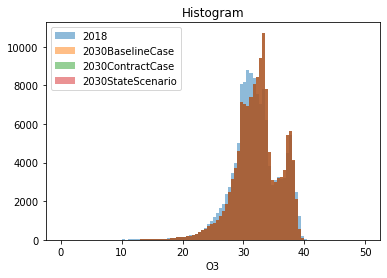

In [59]:
# o3_winter_mean_base_2018.plot.hist(bins=100, range=(0, 50), label='Base 2018', alpha=0.5)
# o3_winter_mean_base_2032.plot.hist(bins=100, range=(0, 50), label='Base 2032', alpha=0.5)
o3_winter_mean_nygrid_2018.plot.hist(
    bins=100, range=(0, 50), label='2018', alpha=0.5)
o3_winter_mean_nygrid_2030BaselineCase.plot.hist(
    bins=100, range=(0, 50), label='2030BaselineCase', alpha=0.5)
o3_winter_mean_nygrid_2030ContractCase.plot.hist(
    bins=100, range=(0, 50), label='2030ContractCase', alpha=0.5)
o3_winter_mean_nygrid_2030StateScenario.plot.hist(
    bins=100, range=(0, 50), label='2030StateScenario', alpha=0.5)
plt.legend()
plt.show()

/home/by276/anaconda3/envs/optwrf_new/lib/python3.7/site-packages/cartopy/mpl/geoaxes.py:1598: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  shading=shading)


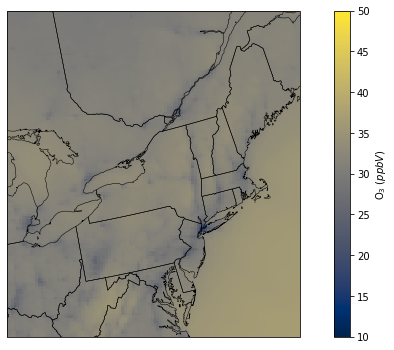

In [60]:
# NYGrid 2018 winter O3 mean
plots.conc_map(o3_winter_mean_nygrid_2018,
               cmap=cm.get_cmap('cividis'),
               figsize=(12, 6), ax=None,
               cartopy_crs=ccrs,
               #    proj_bounds=proj_bounds,
               proj_bounds=closer_bounds,
               vmin=10, vmax=50,
               cbar_args={
                   "cbar_ticks": [10, 15, 20, 25, 30, 35, 40, 45, 50],
                   "cbar_label": 'O$_{3}$ ($ppbV$)'
               },
               savefig=True,
               figpath='../data/plots/winter_o3_mean_nygrid_2018NewParams.png')

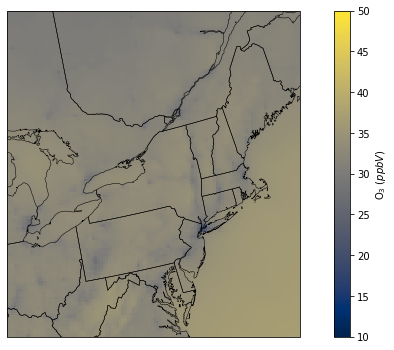

In [61]:
# NYGrid 2030BaselineCase winter O3 mean
plots.conc_map(o3_winter_mean_nygrid_2030BaselineCase,
               cmap=cm.get_cmap('cividis'),
               figsize=(12, 6), ax=None,
               cartopy_crs=ccrs,
               #    proj_bounds=proj_bounds,
               proj_bounds=closer_bounds,
               vmin=10, vmax=50,
               cbar_args={
                   "cbar_ticks": [10, 15, 20, 25, 30, 35, 40, 45, 50],
                   "cbar_label": 'O$_{3}$ ($ppbV$)'
               },
               savefig=True,
               figpath='../data/plots/winter_o3_mean_nygrid_2030BaselineCase.png')

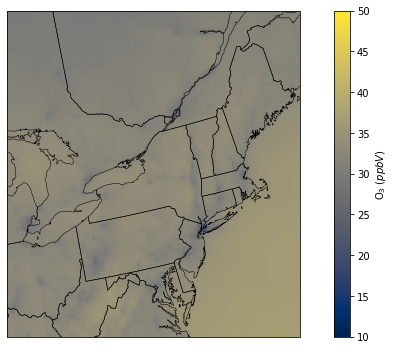

In [62]:
# NYGrid 2030ContractCase winter O3 mean
plots.conc_map(o3_winter_mean_nygrid_2030ContractCase,
               cmap=cm.get_cmap('cividis'),
               figsize=(12, 6), ax=None,
               cartopy_crs=ccrs,
               #    proj_bounds=proj_bounds,
               proj_bounds=closer_bounds,
               vmin=10, vmax=50,
               cbar_args={
                   "cbar_ticks": [10, 15, 20, 25, 30, 35, 40, 45, 50],
                   "cbar_label": 'O$_{3}$ ($ppbV$)'
               },
               savefig=True,
               figpath='../data/plots/winter_o3_mean_nygrid_2030ContractCase.png')

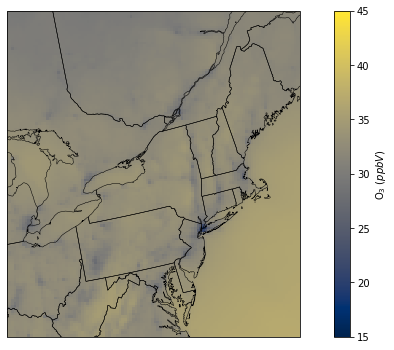

In [63]:
# NYGrid 2030StateScenario winter O3 mean
plots.conc_map(o3_winter_mean_nygrid_2030StateScenario,
               cmap=cm.get_cmap('cividis'),
               figsize=(12, 6), ax=None,
               cartopy_crs=ccrs,
               #    proj_bounds=proj_bounds,
               proj_bounds=closer_bounds,
               vmin=15, vmax=45,
               cbar_args={
                   "cbar_ticks": [15, 20, 25, 30, 35, 40, 45],
                   "cbar_label": 'O$_{3}$ ($ppbV$)'
               },
               savefig=True,
               figpath='../data/plots/winter_o3_mean_nygrid_2030StateScenario.png')

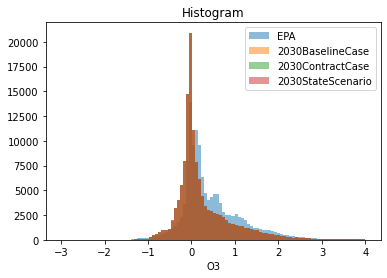

In [64]:
o3_winter_mean_diff_base_2032_2018.plot.hist(
    bins=100, range=(-3, 4), label='EPA', alpha=0.5)
o3_winter_mean_diff_nygrid_2030BaselineCase.plot.hist(
    bins=100, range=(-3, 4), label='2030BaselineCase', alpha=0.5)
o3_winter_mean_diff_nygrid_2030ContractCase.plot.hist(
    bins=100, range=(-3, 4), label='2030ContractCase', alpha=0.5)
o3_winter_mean_diff_nygrid_2030StateScenario.plot.hist(
    bins=100, range=(-3, 4), label='2030StateScenario', alpha=0.5)
plt.legend()
plt.show()

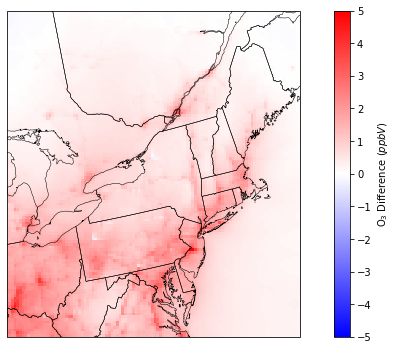

In [65]:
# EPA 2032 - 2018 winter O3 difference mean
plots.conc_map(o3_winter_mean_diff_base_2032_2018,
               cmap=cm.get_cmap('bwr'),
               figsize=(12, 6), ax=None,
               cartopy_crs=ccrs,
               #    proj_bounds=proj_bounds,
               proj_bounds=closer_bounds,
               vmin=-5, vmax=5,
               cbar_args={
                   "cbar_ticks": [-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5],
                   "cbar_label": 'O$_{3}$ Difference ($ppbV$)'
               },
               savefig=True,
               figpath='../data/plots/winter_o3_diff_mean_EPA.png')

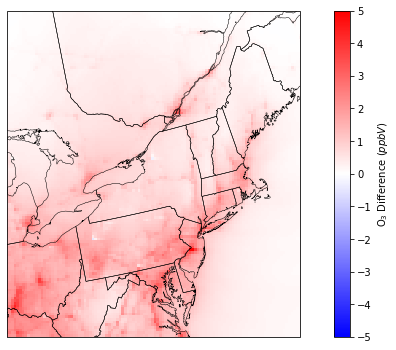

In [66]:
# NYGrid 2030BaselineCase - 2018 winter O3 difference mean
plots.conc_map(o3_winter_mean_diff_nygrid_2030BaselineCase,
               cmap=cm.get_cmap('bwr'),
               figsize=(12, 6), ax=None,
               cartopy_crs=ccrs,
               #    proj_bounds=proj_bounds,
               proj_bounds=closer_bounds,
               vmin=-5, vmax=5,
               cbar_args={
                   "cbar_ticks": [-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5],
                   "cbar_label": 'O$_{3}$ Difference ($ppbV$)'
               },
               savefig=True,
               figpath='../data/plots/winter_o3_diff_mean_2030BaselineCase.png')

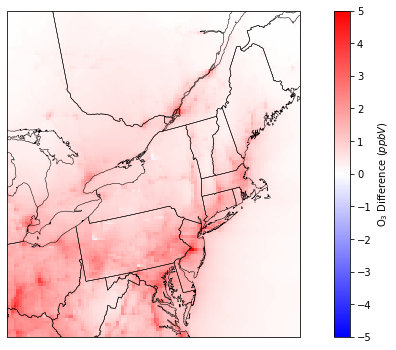

In [67]:
# NYGrid 2030ContractCase - 2018 winter O3 difference mean
plots.conc_map(o3_winter_mean_diff_nygrid_2030ContractCase,
               cmap=cm.get_cmap('bwr'),
               figsize=(12, 6), ax=None,
               cartopy_crs=ccrs,
               #    proj_bounds=proj_bounds,
               proj_bounds=closer_bounds,
               vmin=-5, vmax=5,
               cbar_args={
                   "cbar_ticks": [-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5],
                   "cbar_label": 'O$_{3}$ Difference ($ppbV$)'
               },
               savefig=True,
               figpath='../data/plots/winter_o3_diff_mean_2030ContractCase.png')

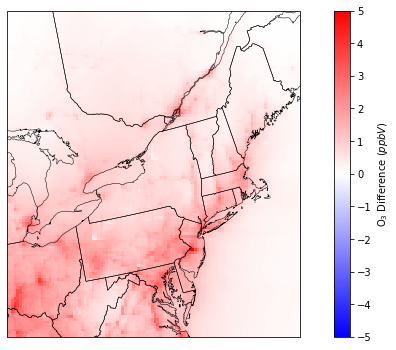

In [68]:
# NYGrid 2030StateScenario - 2018 winter O3 difference mean
plots.conc_map(o3_winter_mean_diff_nygrid_2030StateScenario,
               cmap=cm.get_cmap('bwr'),
               figsize=(12, 6), ax=None,
               cartopy_crs=ccrs,
               #    proj_bounds=proj_bounds,
               proj_bounds=closer_bounds,
               vmin=-5, vmax=5,
               cbar_args={
                   "cbar_ticks": [-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5],
                   "cbar_label": 'O$_{3}$ Difference ($ppbV$)'
               },
               savefig=True,
               figpath='../data/plots/winter_o3_diff_mean_2030StateScenario.png')

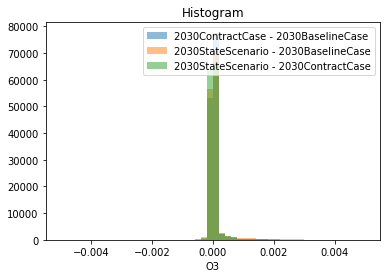

In [69]:
o3_winter_mean_diff_nygrid_2030CC_2030BC.plot.hist(
    bins=50, range=(-0.005, 0.005), label='2030ContractCase - 2030BaselineCase', alpha=0.5)
o3_winter_mean_diff_nygrid_2030SS_2030BC.plot.hist(
    bins=50, range=(-0.005, 0.005), label='2030StateScenario - 2030BaselineCase', alpha=0.5)
o3_winter_mean_diff_nygrid_2030SS_2030CC.plot.hist(
    bins=50, range=(-0.005, 0.005), label='2030StateScenario - 2030ContractCase', alpha=0.5)
plt.legend()
plt.show()

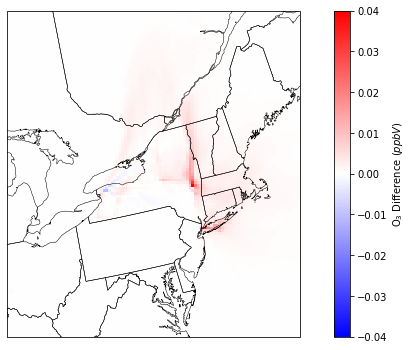

In [70]:
# NYGrid 2030ContractCase - 2030BaselineCase winter O3 percentage difference mean
plots.conc_map(
    o3_winter_mean_diff_nygrid_2030CC_2030BC,
    cmap=cm.get_cmap('bwr'),
    figsize=(12, 6),
    ax=None,
    cartopy_crs=ccrs,
    #    proj_bounds=proj_bounds,
    proj_bounds=closer_bounds,
    vmin=-0.04,
    vmax=0.04,
    cbar_args={
        # "cbar_ticks": [-0.02, -0.01, 0, 0.01, 0.02],
        "cbar_label": 'O$_{3}$ Difference ($ppbV$)',
    },
    savefig=True,
    figpath='../data/plots/winter_pm25_diff_mean_2030CC_2030BC.png'
)

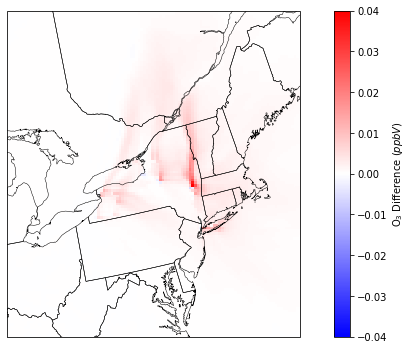

In [71]:
# NYGrid 2030StateScenario - 2030BaselineCase winter O3 percentage difference mean
plots.conc_map(
    o3_winter_mean_diff_nygrid_2030SS_2030BC,
    cmap=cm.get_cmap('bwr'),
    figsize=(12, 6),
    ax=None,
    cartopy_crs=ccrs,
    #    proj_bounds=proj_bounds,
    proj_bounds=closer_bounds,
    vmin=-0.04,
    vmax=0.04,
    cbar_args={
        # "cbar_ticks": [-0.05, -0.04, -0.03, -0.02, -0.01, 0, 0.01, 0.02, 0.03, 0.04, 0.05],
        "cbar_label": 'O$_{3}$ Difference ($ppbV$)',
    },
    savefig=True,
    figpath='../data/plots/winter_pm25_diff_mean_2030SS_2030BC.png'
)

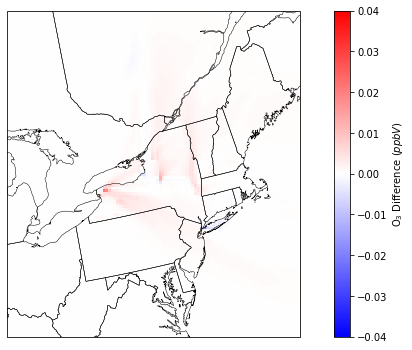

In [72]:
# NYGrid 2030StateScenario - 2030ContractCase winter O3 percentage difference mean
plots.conc_map(
    o3_winter_mean_diff_nygrid_2030SS_2030CC,
    cmap=cm.get_cmap('bwr'),
    figsize=(12, 6),
    ax=None,
    cartopy_crs=ccrs,
    #    proj_bounds=proj_bounds,
    proj_bounds=closer_bounds,
    vmin=-0.04,
    vmax=0.04,
    cbar_args={
        # "cbar_ticks": [-0.05, -0.04, -0.03, -0.02, -0.01, 0, 0.01, 0.02, 0.03, 0.04, 0.05],
        "cbar_label": 'O$_{3}$ Difference ($ppbV$)',
    },
    savefig=True,
    figpath='../data/plots/winter_pm25_diff_mean_2030SS_2030CC.png'
)

### 2.2. Summer Ozone

In [73]:
# Get the plot variables
# EPA Baseline
o3_summer_mean_base_2018 = conc_summer_base_2018['O3'].mean(
    dim='time').squeeze()
o3_summer_mean_base_2032 = conc_summer_base_2032['O3'].mean(
    dim='time').squeeze()

o3_summer_mean_diff_base_2032_2018 = (conc_summer_base_2032['O3']
                                      - conc_summer_base_2018['O3']).mean(dim='time').squeeze()
o3_summer_mean_pct_diff_base_2032_2018 = ((conc_summer_base_2032['O3']
                                           - conc_summer_base_2018['O3'])
                                          / conc_summer_base_2018['O3'] * 100).mean(dim='time').squeeze()

# NYGrid scenarios
o3_summer_mean_nygrid_2018 = conc_summer_nygrid_2018['O3'].mean(
    dim='time').squeeze()

# 1) 2030BaselineCase
o3_summer_mean_nygrid_2030BaselineCase = conc_summer_nygrid_2030BaselineCase['O3'].mean(
    dim='time').squeeze()
o3_summer_mean_diff_nygrid_2030BaselineCase = (conc_summer_nygrid_2030BaselineCase['O3']
                                               - conc_summer_nygrid_2018['O3']).mean(dim='time').squeeze()
o3_summer_mean_pct_diff_nygrid_2030BaselineCase = ((conc_summer_nygrid_2030BaselineCase['O3']
                                                    - conc_summer_nygrid_2018['O3'])
                                                   / conc_summer_nygrid_2018['O3'] * 100).mean(dim='time').squeeze()

# 2) 2030ContractCase
o3_summer_mean_nygrid_2030ContractCase = conc_summer_nygrid_2030ContractCase['O3'].mean(
    dim='time').squeeze()
o3_summer_mean_diff_nygrid_2030ContractCase = (conc_summer_nygrid_2030ContractCase['O3']
                                               - conc_summer_nygrid_2018['O3']).mean(dim='time').squeeze()
o3_summer_mean_pct_diff_nygrid_2030ContractCase = ((conc_summer_nygrid_2030ContractCase['O3']
                                                    - conc_summer_nygrid_2018['O3'])
                                                   / conc_summer_nygrid_2018['O3'] * 100).mean(dim='time').squeeze()

# 3) 2030StateScenario
o3_summer_mean_nygrid_2030StateScenario = conc_summer_nygrid_2030StateScenario['O3'].mean(
    dim='time').squeeze()
o3_summer_mean_diff_nygrid_2030StateScenario = (conc_summer_nygrid_2030StateScenario['O3']
                                                - conc_summer_nygrid_2018['O3']).mean(dim='time').squeeze()
o3_summer_mean_pct_diff_nygrid_2030StateScenario = ((conc_summer_nygrid_2030StateScenario['O3']
                                                     - conc_summer_nygrid_2018['O3'])
                                                    / conc_summer_nygrid_2018['O3'] * 100).mean(dim='time').squeeze()

# 4) Comparison between policy scenarios
o3_summer_mean_diff_nygrid_2030CC_2030BC = (conc_summer_nygrid_2030ContractCase['O3']
                                            - conc_summer_nygrid_2030BaselineCase['O3']).mean(dim='time').squeeze()
o3_summer_mean_pct_diff_nygrid_2030CC_2030BC = ((conc_summer_nygrid_2030ContractCase['O3']
                                                    - conc_summer_nygrid_2030BaselineCase['O3'])
                                                    / conc_summer_nygrid_2030BaselineCase['O3'] * 100).mean(dim='time').squeeze()

o3_summer_mean_diff_nygrid_2030SS_2030BC = (conc_summer_nygrid_2030StateScenario['O3']
                                            - conc_summer_nygrid_2030BaselineCase['O3']).mean(dim='time').squeeze()
o3_summer_mean_pct_diff_nygrid_2030SS_2030BC = ((conc_summer_nygrid_2030StateScenario['O3']
                                                - conc_summer_nygrid_2030BaselineCase['O3'])
                                                / conc_summer_nygrid_2030BaselineCase['O3'] * 100).mean(dim='time').squeeze()

o3_summer_mean_diff_nygrid_2030SS_2030CC = (conc_summer_nygrid_2030StateScenario['O3']
                                            - conc_summer_nygrid_2030ContractCase['O3']).mean(dim='time').squeeze()
o3_summer_mean_pct_diff_nygrid_2030SS_2030CC = ((conc_summer_nygrid_2030StateScenario['O3']
                                                - conc_summer_nygrid_2030ContractCase['O3'])
                                                / conc_summer_nygrid_2030ContractCase['O3'] * 100).mean(dim='time').squeeze()

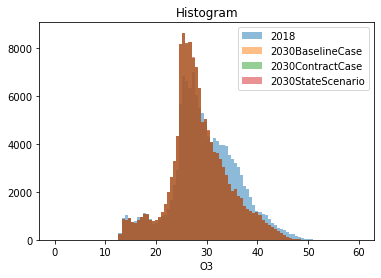

In [74]:
# o3_summer_mean_base_2018.plot.hist(bins=100, range=(0, 60), label='Base 2018', alpha=0.5)
# o3_summer_mean_base_2032.plot.hist(bins=100, range=(0, 60), label='Base 2032', alpha=0.5)
o3_summer_mean_nygrid_2018.plot.hist(
    bins=100, range=(0, 60), label='2018', alpha=0.5)
o3_summer_mean_nygrid_2030BaselineCase.plot.hist(
    bins=100, range=(0, 60), label='2030BaselineCase', alpha=0.5)
o3_summer_mean_nygrid_2030ContractCase.plot.hist(
    bins=100, range=(0, 60), label='2030ContractCase', alpha=0.5)
o3_summer_mean_nygrid_2030StateScenario.plot.hist(
    bins=100, range=(0, 60), label='2030StateScenario', alpha=0.5)
plt.legend()
plt.show()

/home/by276/anaconda3/envs/optwrf_new/lib/python3.7/site-packages/cartopy/mpl/geoaxes.py:1598: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  shading=shading)


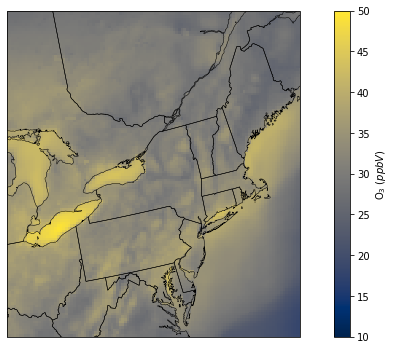

In [75]:
# NYGrid 2018 summer O3 mean
plots.conc_map(o3_summer_mean_nygrid_2018,
               cmap=cm.get_cmap('cividis'),
               figsize=(12, 6), ax=None,
               cartopy_crs=ccrs,
               #    proj_bounds=proj_bounds,
               proj_bounds=closer_bounds,
               vmin=10, vmax=50,
               cbar_args={
                   "cbar_ticks": [10, 15, 20, 25, 30, 35, 40, 45, 50],
                   "cbar_label": 'O$_{3}$ ($ppbV$)'
               },
               savefig=True,
               figpath='../data/plots/winter_o3_mean_nygrid_2018NewParams.png')

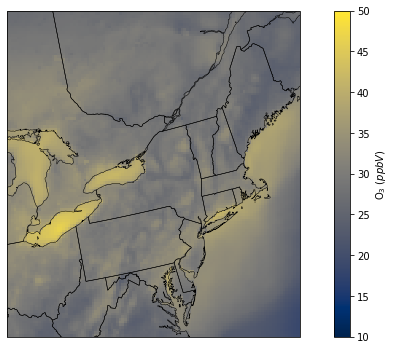

In [76]:
# NYGrid 2030BaselineCase summer O3 mean
plots.conc_map(o3_summer_mean_nygrid_2030BaselineCase,
               cmap=cm.get_cmap('cividis'),
               figsize=(12, 6), ax=None,
               cartopy_crs=ccrs,
               #    proj_bounds=proj_bounds,
               proj_bounds=closer_bounds,
               vmin=10, vmax=50,
               cbar_args={
                   "cbar_ticks": [10, 15, 20, 25, 30, 35, 40, 45, 50],
                   "cbar_label": 'O$_{3}$ ($ppbV$)'
               },
               savefig=True,
               figpath='../data/plots/winter_o3_mean_nygrid_2030BaselineCase.png')

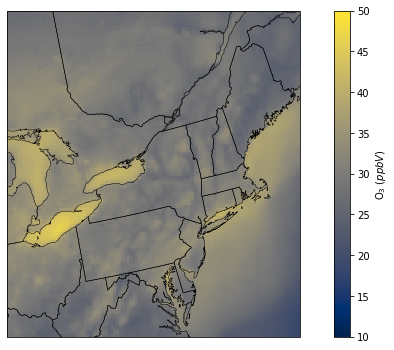

In [77]:
# NYGrid 2030ContractCase summer O3 mean
plots.conc_map(o3_summer_mean_nygrid_2030ContractCase,
               cmap=cm.get_cmap('cividis'),
               figsize=(12, 6), ax=None,
               cartopy_crs=ccrs,
               #    proj_bounds=proj_bounds,
               proj_bounds=closer_bounds,
               vmin=10, vmax=50,
               cbar_args={
                   "cbar_ticks": [10, 15, 20, 25, 30, 35, 40, 45, 50],
                   "cbar_label": 'O$_{3}$ ($ppbV$)'
               },
               savefig=True,
               figpath='../data/plots/winter_o3_mean_nygrid_2030ContractCase.png')

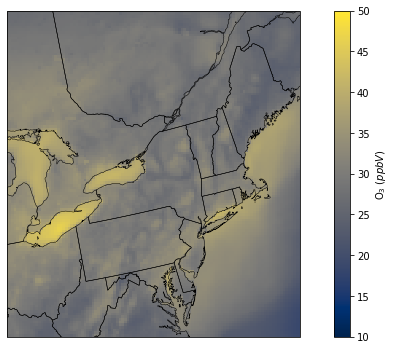

In [78]:
# NYGrid 2030StateScenario summer O3 mean
plots.conc_map(o3_summer_mean_nygrid_2030StateScenario,
               cmap=cm.get_cmap('cividis'),
               figsize=(12, 6), ax=None,
               cartopy_crs=ccrs,
               #    proj_bounds=proj_bounds,
               proj_bounds=closer_bounds,
               vmin=10, vmax=50,
               cbar_args={
                   "cbar_ticks": [10, 15, 20, 25, 30, 35, 40, 45, 50],
                   "cbar_label": 'O$_{3}$ ($ppbV$)'
               },
               savefig=True,
               figpath='../data/plots/winter_o3_mean_nygrid_2030StateScenario.png')

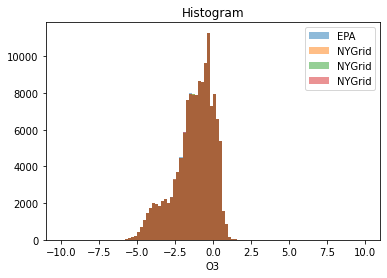

In [79]:
o3_summer_mean_diff_base_2032_2018.plot.hist(
    bins=100, range=(-10, 10), label='EPA', alpha=0.5)
o3_summer_mean_diff_nygrid_2030BaselineCase.plot.hist(
    bins=100, range=(-10, 10), label='NYGrid', alpha=0.5)
o3_summer_mean_diff_nygrid_2030ContractCase.plot.hist(
    bins=100, range=(-10, 10), label='NYGrid', alpha=0.5)
o3_summer_mean_diff_nygrid_2030StateScenario.plot.hist(
    bins=100, range=(-10, 10), label='NYGrid', alpha=0.5)
plt.legend()
plt.show()

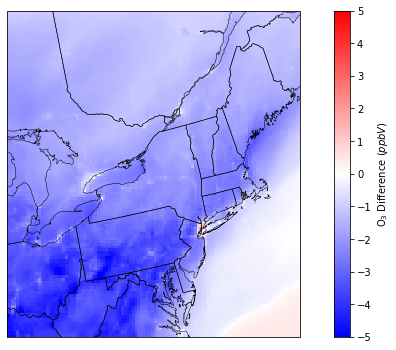

In [80]:
# EPA 2032 - 2018 summer O3 difference mean
plots.conc_map(o3_summer_mean_diff_base_2032_2018,
               cmap=cm.get_cmap('bwr'),
               figsize=(12, 6), ax=None,
               cartopy_crs=ccrs,
               #    proj_bounds=proj_bounds,
               proj_bounds=closer_bounds,
               vmin=-5, vmax=5,
               cbar_args={
                   "cbar_ticks": [-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5],
                   "cbar_label": 'O$_{3}$ Difference ($ppbV$)'
               },
               savefig=True,
               figpath='../data/plots/winter_o3_diff_mean_EPA.png')

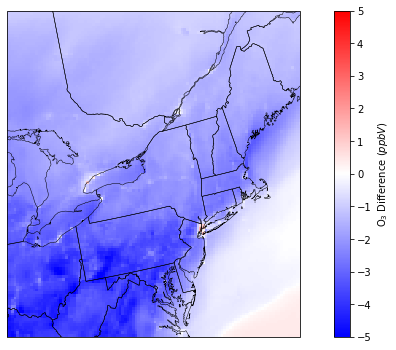

In [81]:
# NYGrid 2030BaselineCase - 2018 summer O3 difference mean
plots.conc_map(o3_summer_mean_diff_nygrid_2030BaselineCase,
               cmap=cm.get_cmap('bwr'),
               figsize=(12, 6), ax=None,
               cartopy_crs=ccrs,
               #    proj_bounds=proj_bounds,
               proj_bounds=closer_bounds,
               vmin=-5, vmax=5,
               cbar_args={
                   "cbar_ticks": [-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5],
                   "cbar_label": 'O$_{3}$ Difference ($ppbV$)'
               },
               savefig=True,
               figpath='../data/plots/winter_o3_diff_mean_2030BaselineCase.png')

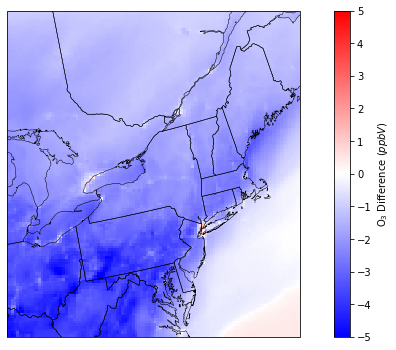

In [82]:
# NYGrid 2030ContractCase - 2018 summer O3 difference mean
plots.conc_map(o3_summer_mean_diff_nygrid_2030ContractCase,
               cmap=cm.get_cmap('bwr'),
               figsize=(12, 6), ax=None,
               cartopy_crs=ccrs,
               #    proj_bounds=proj_bounds,
               proj_bounds=closer_bounds,
               vmin=-5, vmax=5,
               cbar_args={
                   "cbar_ticks": [-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5],
                   "cbar_label": 'O$_{3}$ Difference ($ppbV$)'
               },
               savefig=True,
               figpath='../data/plots/winter_o3_diff_mean_2030ContractCase.png')

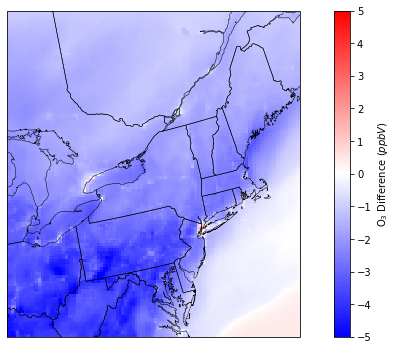

In [83]:
# NYGrid 2030StateScenario - 2018 summer O3 difference mean
plots.conc_map(o3_summer_mean_diff_nygrid_2030StateScenario,
               cmap=cm.get_cmap('bwr'),
               figsize=(12, 6), ax=None,
               cartopy_crs=ccrs,
               #    proj_bounds=proj_bounds,
               proj_bounds=closer_bounds,
               vmin=-5, vmax=5,
               cbar_args={
                   "cbar_ticks": [-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5],
                   "cbar_label": 'O$_{3}$ Difference ($ppbV$)'
               },
               savefig=True,
               figpath='../data/plots/winter_o3_diff_mean_2030StateScenario.png')

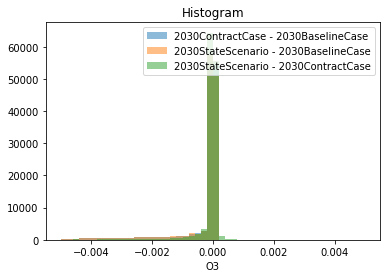

In [84]:
o3_summer_mean_diff_nygrid_2030CC_2030BC.plot.hist(
    bins=50, range=(-0.005, 0.005), label='2030ContractCase - 2030BaselineCase', alpha=0.5)
o3_summer_mean_diff_nygrid_2030SS_2030BC.plot.hist(
    bins=50, range=(-0.005, 0.005), label='2030StateScenario - 2030BaselineCase', alpha=0.5)
o3_summer_mean_diff_nygrid_2030SS_2030CC.plot.hist(
    bins=50, range=(-0.005, 0.005), label='2030StateScenario - 2030ContractCase', alpha=0.5)
plt.legend()
plt.show()

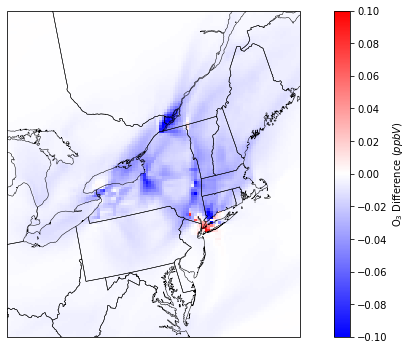

In [85]:
# NYGrid 2030ContractCase - 2030BaselineCase summer O3 percentage difference mean
plots.conc_map(
    o3_summer_mean_diff_nygrid_2030CC_2030BC,
    cmap=cm.get_cmap('bwr'),
    figsize=(12, 6),
    ax=None,
    cartopy_crs=ccrs,
    #    proj_bounds=proj_bounds,
    proj_bounds=closer_bounds,
    vmin=-0.1,
    vmax=0.1,
    cbar_args={
        "cbar_ticks": [-0.1, -0.08, -0.06, -0.04, -0.02, 0, 0.02, 0.04, 0.06, 0.08, 0.1],
        "cbar_label": 'O$_{3}$ Difference ($ppbV$)',
    },
    savefig=True,
    figpath='../data/plots/winter_pm25_diff_mean_2030CC_2030BC.png'
)

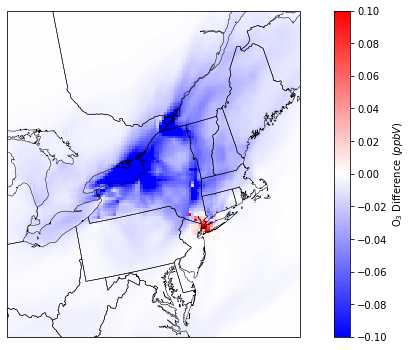

In [86]:
# NYGrid 2030StateScenario - 2030BaselineCase summer O3 percentage difference mean
plots.conc_map(
    o3_summer_mean_diff_nygrid_2030SS_2030BC,
    cmap=cm.get_cmap('bwr'),
    figsize=(12, 6),
    ax=None,
    cartopy_crs=ccrs,
    #    proj_bounds=proj_bounds,
    proj_bounds=closer_bounds,
    vmin=-0.1,
    vmax=0.1,
    cbar_args={
        "cbar_ticks": [-0.1, -0.08, -0.06, -0.04, -0.02, 0, 0.02, 0.04, 0.06, 0.08, 0.1],
        "cbar_label": 'O$_{3}$ Difference ($ppbV$)',
    },
    savefig=True,
    figpath='../data/plots/winter_pm25_diff_mean_2030SS_2030BC.png'
)

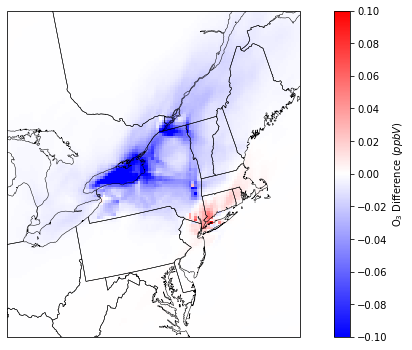

In [87]:
# NYGrid 2030StateScenario - 2030ContractCase summer O3 percentage difference mean
plots.conc_map(
    o3_summer_mean_diff_nygrid_2030SS_2030CC,
    cmap=cm.get_cmap('bwr'),
    figsize=(12, 6),
    ax=None,
    cartopy_crs=ccrs,
    #    proj_bounds=proj_bounds,
    proj_bounds=closer_bounds,
    vmin=-0.1,
    vmax=0.1,
    cbar_args={
        "cbar_ticks": [-0.1, -0.08, -0.06, -0.04, -0.02, 0, 0.02, 0.04, 0.06, 0.08, 0.1],
        "cbar_label": 'O$_{3}$ Difference ($ppbV$)',
    },
    savefig=True,
    figpath='../data/plots/winter_pm25_diff_mean_2030SS_2030CC.png'
)